<a href="https://colab.research.google.com/github/armybonita/Good-Energy-Intelligence-Score/blob/main/%EB%94%A5%EB%9F%AC%EB%8B%9D%EC%8B%A4%EC%8A%B5_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. 딥러닝을 위한 데이터셋 준비하기

## MNIST 손글씨 숫자 인식 학습

MNIST 데이터넷은 0~9까지 손글씨 훈련이미지 6만장, 시험이미지 1만장이 준비되어있다.

28 * 28 크기 회색조 이미지이며, 각 픽셀은 0~255까지 값을 취한다. 또한 레이블도 포함되어있다.

MNIST 파일은 웹사이트(https://github.com/tensorflow/tensorflow/tree/master/tensorflow/examples/tutorials/mnist) 에서 다운받을 수 있다.

In [ ]:
import sys, os

# Ensure 'dataset' directory exists
dataset_dir = 'dataset'
if not os.path.exists(dataset_dir):
    os.makedirs(dataset_dir)

# Ensure 'common' directory exists
common_dir = 'common' # This should be a sibling to 'dataset'
if not os.path.exists(common_dir):
    os.makedirs(common_dir)

# URLs for files from the deep-learning-from-scratch repository
mnist_url = "https://raw.githubusercontent.com/oreilly-japan/deep-learning-from-scratch/master/dataset/mnist.py"
functions_url = "https://raw.githubusercontent.com/oreilly-japan/deep-learning-from-scratch/master/common/functions.py"
gradient_url = "https://raw.githubusercontent.com/oreilly-japan/deep-learning-from-scratch/master/common/gradient.py"

# Download mnist.py
if not os.path.exists(os.path.join(dataset_dir, 'mnist.py')):
    print(f"Downloading {mnist_url} to {dataset_dir}/mnist.py...")
    !wget -q -P {dataset_dir}/ {mnist_url}

# Download functions.py
if not os.path.exists(os.path.join(common_dir, 'functions.py')):
    print(f"Downloading {functions_url} to {common_dir}/functions.py...")
    !wget -q -P {common_dir}/ {functions_url}

# Download gradient.py
if not os.path.exists(os.path.join(common_dir, 'gradient.py')):
    print(f"Downloading {gradient_url} to {common_dir}/gradient.py...")
    !wget -q -P {common_dir}/ {gradient_url}

# Create __init__.py in dataset if it doesn't exist to treat it as a package
if not os.path.exists(os.path.join(dataset_dir, '__init__.py')):
    with open(os.path.join(dataset_dir, '__init__.py'), 'w') as f:
        pass

# Create __init__.py in common if it doesn't exist to treat it as a package
if not os.path.exists(os.path.join(common_dir, '__init__.py')):
    with open(os.path.join(common_dir, '__init__.py'), 'w') as f:
        pass

# Add the current directory (base_dir) to sys.path so 'dataset' and 'common' can be imported
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)

# Import statements
from dataset.mnist import load_mnist
from PIL import Image
import pickle

import numpy as np
import matplotlib.pylab as plt

### 데이터셋 로드

In [ ]:
(x_train, t_train), (x_test, t_test) = load_mnist(flatten=True, normalize=False, one_hot_label=False)

Done
Done
Done
Done
Converting train-images-idx3-ubyte.gz to NumPy Array ...
Done
Converting train-labels-idx1-ubyte.gz to NumPy Array ...
Done
Converting t10k-images-idx3-ubyte.gz to NumPy Array ...
Done
Converting t10k-labels-idx1-ubyte.gz to NumPy Array ...
Done
Creating pickle file ...
Done!


normalize는 0.0\~1.0사이 값으로 정규화 할지를 정한다(안할 경우 0\~255)

flatten 입력이미지를 평탄하게(1차원) 만들지 정한다. 안할 경우 1 * 28 * 28 3차원배열로 true로하면 784개의 원소로 이루어진 1차원 배열로 저장한다.

one_hot_label은 레이블을 원-핫-인코딩형태로 저장할지 정한다. false일 경우 숫자형태 레이블로 저장한다.

각 데이터셋의 형태는 다음과 같다.

In [ ]:
print(x_train.shape)
print(t_train.shape)
print(x_test.shape)
print(t_test.shape)

(60000, 784)
(60000,)
(10000, 784)
(10000,)


파이썬의 pickle 기능으로 프로그램 실행중 특정 객체를 파일로 저장한다. 저장한 pickle 파일을 로드하면 실행 당시의 객체를 즉시 복원할 수 있다.

load_mnist()함수도 2번째 읽을 때 pickle을 이용하여 빠르게 준비할 수 있다.

### 로드 이미지 출력

간단한 함수로 불러온 데이터셋의 이미지를 출력해본다.

In [ ]:
def img_show(img):
    # pil_img = Image.fromarray(np.uint8(img)) # np로 저장된 이미지 데이터를 pil용 데이터 객체로 변환
    # pil_img.show()
    plt.imshow(img, cmap='gray') # Display image using matplotlib
    plt.axis('off') # Hide axes
    plt.show()

(x_train, t_train), (x_test, t_test) = \
    load_mnist(flatten=True, normalize=False)

img = x_train[13]
label = t_train[13]
print(label)

print(img.shape)
img = img.reshape(28,28) # 1차원 배열로 받아온 이미지를 28*28 이미지로 다시 변환
print(img.shape)

6
(784,)
(28, 28)


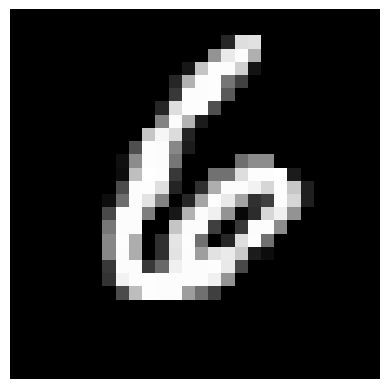

In [ ]:
img_show(img)

# 2. Pytorch 를 사용하여 딥러닝 모델 만들기 (MLP)

이번 섹션에서는 MNIST를 학습하기 위한 딥러닝 모델을 Pytorch를 사용하여 쉽게 구성해볼 예정이다.

현재까지 공개된 최신 딥러닝 모델의 90%가 PyTorch로 구성되어 있다.

## 환경 설정 및 데이터 준비

In [ ]:
import torch
import torchvision

In [ ]:
random_seed = 1
torch.backends.cudnn.enabled = True
torch.manual_seed(random_seed)

여기서 에포크(epoch)는 전체 학습 데이터셋에 대한 반복 횟수이며, 학습률(learning_rate)과 모멘텀(momentum)은 추후 사용할 최적화 기법(optimizer)의 하이퍼파라미터이다.

재현 가능한 실험을 위해 난수 생성을 수반하는 모든 모듈(NumPy 및 random 포함)의 시드(seed)를 고정해야 한다.


### Pytorch의 데이터 로더 함수

데이터셋 처리를 위해 DataLoader를 구축한다.

![image](https://blog.kakaocdn.net/dna/k24n4/btrCHb6e0hy/AAAAAAAAAAAAAAAAAAAAAOE8M8eQbi7pYthSZKRub1cxlUZhDvj30UNCYuY5C6KZ/img.png?credential=yqXZFxpELC7KVnFOS48ylbz2pIh7yKj8&expires=1777561199&allow_ip=&allow_referer=&signature=9ooTGA8fpMQ5PoHUBRtioVd288M%3D)


위 그림과 같이 데이터셋을 모두 한꺼번에 모델에 주기 어려우므로, 데이터를 batch_size로 나누는 작업을 수행한다.

이때 모든 데이터를 전부 학습하는 것을 한 epoch이라 하며, 1 epoch를 학습하기 위해 batch_size를 몇번 불러와야 하는 가를 iteration이라고 한다.

In [ ]:
n_epochs = 3 # 반복 횟수
batch_size = 128 # batch_size

TorchVision을 활용하여 MNIST 데이터셋을 로드하며, 배치 크기(batch_size)는 128으로 설정한다.

In [ ]:
train_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST('/files/', train=True, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ])),
  batch_size=batch_size, shuffle=True)

test_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST('/files/', train=False, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ])),
  batch_size=batch_size, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.54MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.84MB/s]


하단의 Normalize() 변환에 적용된 값 0.1307과 0.3081은 MNIST 데이터셋의 전역 평균 및 표준편차로, 본 실험에서는 해당 값을 상수로 채택한다.

Normalize에 사용되는 평균 및 표준편차는 데이터셋 마다 다르므로, 새로운 데이터셋에 대해 모델을 구축할 경우 새로 구해주는 것이 학습 안정성에 매우 좋다.

인공지능 모델에 데이터를 공급하는 DataLoader(데이터 로더)는 단순히 데이터를 묶는 것 외에도 연산 효율을 높이는 핵심 기능들을 제공한다.

- 다중 작업자 할당 (num_workers > 1): 데이터를 저장소에서 읽어와 모델에 맞게 준비하는 과정에 여러 명의 작업자(서브프로세스)를 투입하는 기능이다. 다수의 작업자가 데이터를 학습과 동시에 준비하므로 대기 시간이 대폭 줄어든다.

In [ ]:
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)
example_data.shape

torch.Size([128, 1, 28, 28])

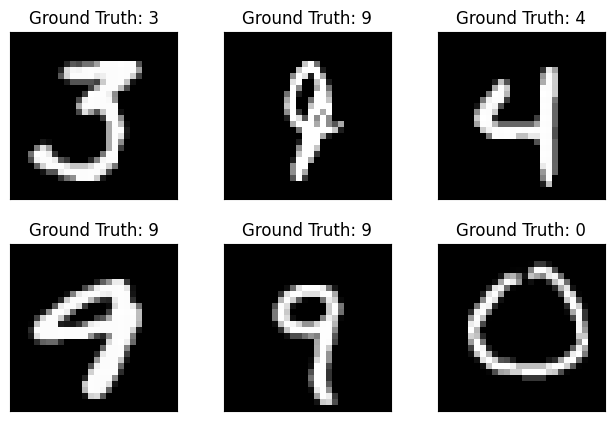

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure()
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Ground Truth: {}".format(example_targets[i]))
  plt.xticks([])
  plt.yticks([])

### 1D(Flatten) 형태 확인 시각화

원본 이미지 shape: (28, 28), flattened shape: (784,)


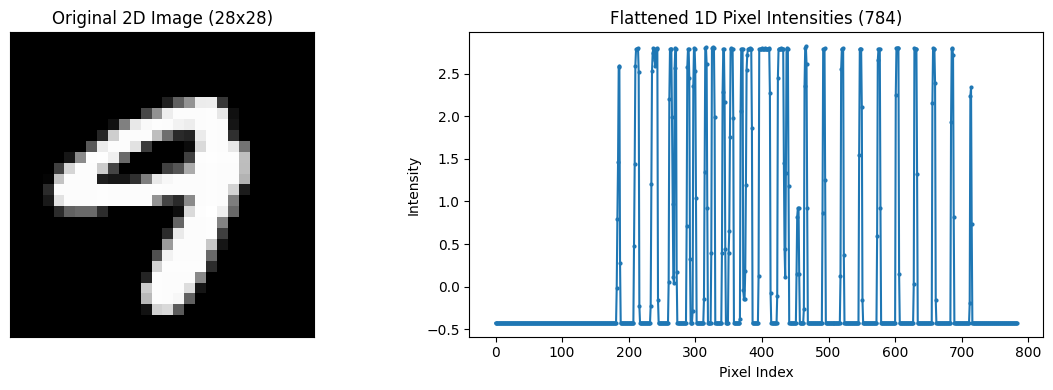

In [ ]:

import matplotlib.pyplot as plt

# 예시 데이터 가져오기
x_sample = example_data[3]

# 원본 이미지 (28x28)와 1D 평탄화 데이터 준비
img_2d = x_sample[0].cpu().numpy() # Remove channel dimension and convert to numpy
x1d = x_sample.view(-1).cpu().numpy()

print(f"원본 이미지 shape: {img_2d.shape}, flattened shape: {x1d.shape}")

# 2개의 서브플롯 생성
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 왼쪽 서브플롯: 2D 이미지
axes[0].imshow(img_2d, cmap='gray', interpolation='none')
axes[0].set_title('Original 2D Image (28x28)')
axes[0].set_xticks([])
axes[0].set_yticks([])

# 오른쪽 서브플롯: 1D 평탄화 데이터
axes[1].plot(x1d, '-o', markersize=2)
axes[1].set_title('Flattened 1D Pixel Intensities (784)')
axes[1].set_xlabel('Pixel Index')
axes[1].set_ylabel('Intensity')

plt.tight_layout()
plt.show()

## 네트워크 만들기

![image](https://towardsdatascience.com/wp-content/uploads/2022/06/1MmrWSRkddKWmY7uAnp6DgQ.jpeg)


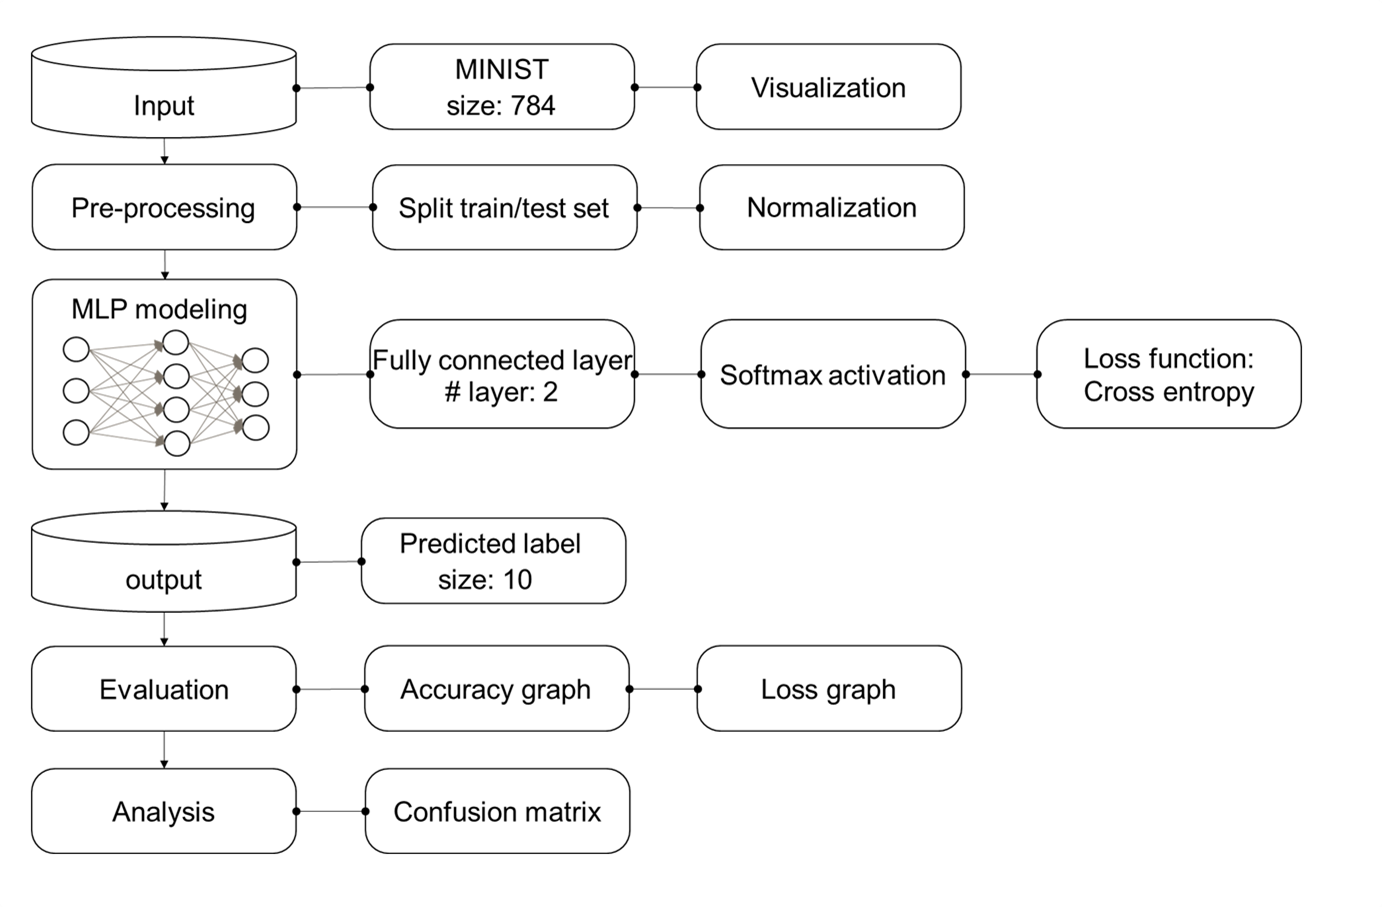

앞선 다른 모델과 같이 본 모델은 2개의 layer를 사용하며, 입력층과 출력층을 구현할 예정이다.

활성화 함수는 ReLu를 사용하고 loss 는 cross entrophy loss 를 사용한다.

torch.nn 모듈은 학습 가능한 파라미터를 포함하는 상태 기반(Stateful) 계층을 의미한다.

torch.nn.functional은 순수 함수형(Stateless) 연산을 수행한다.

forward() 함수는 주어진 계층과 함수를 활용하여 출력값을 산출하는 순전파(Forward pass) 과정을 정의한다.


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TwoLayerMLP(nn.Module):
    def __init__(self, input_size: int = 784, hidden_size: int = 100, output_size: int = 10): # 모델의 구조를 설정하는 파트
        super(TwoLayerMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size) # Input -> First Layer
        self.fc2 = nn.Linear(hidden_size, output_size) # First Layer -> Second Layer


    def forward(self, x: torch.Tensor) -> torch.Tensor: # 모델의 동작 과정을 설정하는 파트
        x = x.view(x.size(0), -1) # 입력 평탄화, MLP는 입력 데이터를 한 줄로만 받는다. 따라서 1차원 형태로 바꿔주는 작업을 수행한다.
        x = F.relu(self.fc1(x)) # Activation 함수 결합
        x = self.fc2(x)

        return x

이후 네트워크 아키텍처와 최적화 알고리즘(Optimizer)을 초기화한다.

In [ ]:
#학습을 위한 다양한 파라미터
learning_rate = 0.01
momentum = 0.5
log_interval = 10

In [ ]:
network = TwoLayerMLP() # Model 생성
optimizer = optim.SGD(network.parameters(), lr=learning_rate, momentum=momentum) # Optimizer: SGD 적용

In [ ]:
train_losses = []
train_counter = []
test_losses = []
test_counter = [i*len(train_loader.dataset) for i in range(n_epochs + 1)]

## 모델 학습 및 추론 loop 만들기

제안하는 방법의 학습 루프(Training loop) 구성은 다음과 같다.

1. 상태 전환 및 데이터 로딩: 네트워크를 학습 모드(train())로 설정한 후, 에포크(Epoch)마다 전체 학습 데이터를 순회한다. 개별 배치(Batch) 처리는 DataLoader를 통해 수행된다.

2. 기울기 초기화: PyTorch의 자동 미분 엔진은 기본적으로 기울기(Gradient)를 누적(Accumulate)하도록 설계되어 있으므로, 매 반복(Iteration)마다 optimizer.zero_grad()를 호출하여 기울기를 $0$으로 초기화해야 한다.

3. 순전파 및 목적 함수 계산: 제안하는 방법의 순전파(Forward pass)를 통해 원시 로짓(Logit) $z$를 산출하고, 예측 로짓과 정답 레이블 $y$ 간의 교차 엔트로피 손실($\mathcal{L}_{CE}$)을 연산한다. PyTorch의 nn.CrossEntropyLoss는 내부적으로 $\text{LogSoftmax}$와 $\text{NLLLoss}$ 연산을 결합한다.

4. 역전파 및 파라미터 갱신: backward()를 호출하여 파라미터 $\theta$에 대한 기울기 $\nabla_{\theta} \mathcal{L}$를 계산한 뒤, optimizer.step()을 통해 가중치를 갱신한다. (PyTorch 자동 미분 시스템(Autograd)의 수학적 작동 원리는 공식 문서 참조)

5. 지표 모니터링: 학습 진행 상태를 추적하며, 손실 함수 수렴 곡선(Learning curve) 시각화를 위해 학습 및 테스트 손실 값을 배열에 저장한다. 시각화 시 X축은 네트워크가 학습한 누적 데이터 샘플 수로 정의한다.

In [ ]:
def train(epoch):
  network.train()
  # 저장 경로 확인 및 생성
  import os
  if not os.path.exists('./results'):
      os.makedirs('./results')

  for batch_idx, (data, target) in enumerate(train_loader):

    # 실제 학습 코드는 5줄

    optimizer.zero_grad() # 1. optimizer 초기화
    output = network(data) # 2. 모델의 출력 확인
    loss = F.cross_entropy(output, target) # 3. 얼마나 틀렸는 지 계산
    loss.backward() # 4. 틀린 것을 보정하도록 학습
    optimizer.step() # 5. optimizer 개선

    #아래는 출력을 위한 코드, 없어도 무방
    if batch_idx % log_interval == 0:
      print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(epoch, batch_idx * len(data), len(train_loader.dataset),100. * batch_idx / len(train_loader), loss.item()))
      train_losses.append(loss.item())
      train_counter.append((batch_idx*64) + ((epoch-1)*len(train_loader.dataset)))
      # 경로를 상대경로로 수정
      torch.save(network.state_dict(), './results/model.pth')
      torch.save(optimizer.state_dict(), './results/optimizer.pth')

제안하는 방법의 학습 및 평가 파이프라인 구성은 다음과 같다.

1. 사전 검증 (Pre-training Evaluation): 학습을 시작하기 전, 무작위로 초기화된 네트워크 파라미터 상태에서의 기준 성능(Baseline performance)을 측정하기 위해 테스트 루프를 1회 수행한다. (이론적 기대 정확도: $10\%$)

2. 상태 보존 (State Management): 제안하는 방법의 신경망 모듈 및 옵티마이저는 .state_dict() 메서드를 통해 내부 상태(Internal state)를 직렬화(Serialization)하여 저장할 수 있다. 이를 통해 이전에 저장된 상태 사전(State dictionary)을 .load_state_dict()로 호출하여 중단된 학습을 재개(Resume training)할 수 있다.

3. 평가 지표 산출 (Evaluation Metrics): 테스트 루프에서는 네트워크의 정확도를 산출하기 위해 누적 테스트 손실(Test loss)을 연산하고 올바르게 분류된 표본 수를 추적한다.

4. 추론 최적화 (Inference Optimization): 테스트 평가 시 torch.no_grad() 컨텍스트 매니저를 적용하여, 네트워크 출력 산출 과정에서 발생하는 동적 연산 그래프(Dynamic computation graph) 구축을 차단하고 메모리 효율을 극대화한다.

5. 최적화 실행 (Execution): 본격적인 최적화 과정을 실행한다. 전체 에포크(Epochs) 반복 루프 진입 전, 무작위 초기화 모델의 검증을 위해 명시적으로 평가 함수를 호출한다.

In [ ]:
def test():
  network.eval()
  test_loss = 0
  correct = 0
  with torch.no_grad():
    for data, target in test_loader:
      output = network(data)
      test_loss += F.cross_entropy(output, target, size_average=False).item()
      pred = output.data.max(1, keepdim=True)[1]
      correct += pred.eq(target.data.view_as(pred)).sum()
  test_loss /= len(test_loader.dataset)
  test_losses.append(test_loss)
  print('\nTest set: Avg. loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(test_loss, correct, len(test_loader.dataset),100. * correct / len(test_loader.dataset)))

In [ ]:
test()
for epoch in range(1, n_epochs + 1):
  train(epoch)
  test()

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:3503: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  reduction = _Reduction.legacy_get_string(size_average, reduce)



Test set: Avg. loss: 2.3306, Accuracy: 729/10000 (7%)

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.316454
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.138673
Train Epoch: 1 [2560/60000 (4%)]	Loss: 1.857233
Train Epoch: 1 [3840/60000 (6%)]	Loss: 1.558025
Train Epoch: 1 [5120/60000 (9%)]	Loss: 1.250890
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.103011
Train Epoch: 1 [7680/60000 (13%)]	Loss: 0.908907
Train Epoch: 1 [8960/60000 (15%)]	Loss: 0.813232
Train Epoch: 1 [10240/60000 (17%)]	Loss: 0.757598
Train Epoch: 1 [11520/60000 (19%)]	Loss: 0.733840
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.611777
Train Epoch: 1 [14080/60000 (23%)]	Loss: 0.532300
Train Epoch: 1 [15360/60000 (26%)]	Loss: 0.664194
Train Epoch: 1 [16640/60000 (28%)]	Loss: 0.601373
Train Epoch: 1 [17920/60000 (30%)]	Loss: 0.595234
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.562157
Train Epoch: 1 [20480/60000 (34%)]	Loss: 0.431524
Train Epoch: 1 [21760/60000 (36%)]	Loss: 0.484764
Train Epoch: 1 [23040/60000 (38%)]	Loss: 0.362633
Train Epoc

## 모델 성능 시각화 및 평가하기

정량적 성능 지표: 제안하는 방법은 단 $3$ 에포크(Epochs)의 최적화 과정을 통해 테스트 데이터셋에서 $90%$ 이상의 정확도를 달성하였다. 학습 전 무작위 초기화 상태에서는 이론적 기댓값에 부합하는 약 $10%$ 정도의 초기 성능을 기록하였다.


In [ ]:
test_counter

[0, 60000, 120000, 180000]

In [ ]:
test_losses

[2.3305571491241457,
 0.32157520189285277,
 0.2700765344262123,
 0.24051992762088775]

Text(0, 0.5, 'negative log likelihood loss')

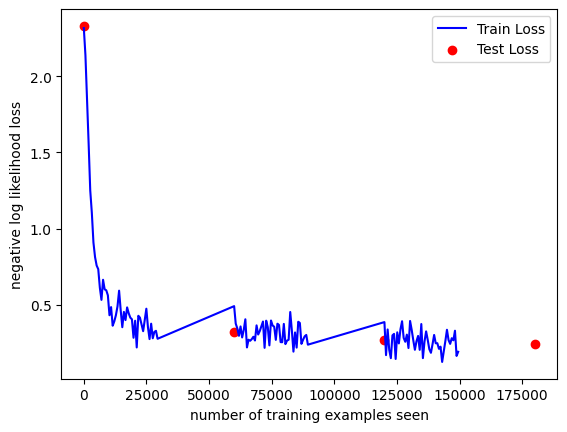

In [ ]:
fig = plt.figure()
plt.plot(train_counter, train_losses, color='blue')
plt.scatter(test_counter, test_losses, color='red')
plt.legend(['Train Loss', 'Test Loss'], loc='upper right')
plt.xlabel('number of training examples seen')
plt.ylabel('negative log likelihood loss')

학습 수렴 곡선 분석: 도출된 학습 곡선(Training curve)의 궤적을 분석한 결과, 목적 함수가 아직 완전히 수렴(Convergence)하지 않았음을 확인하였다. 이는 에포크 수를 증가시켜 추가적인 최적화를 진행할 경우 성능 향상의 여지가 존재함을 시사한다.

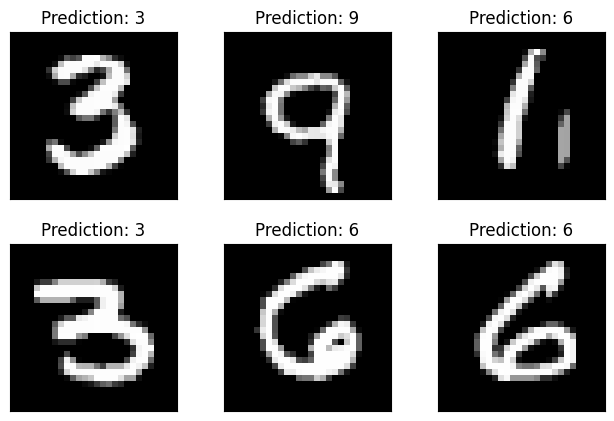

In [ ]:
with torch.no_grad():
  output = network(example_data)

fig = plt.figure()
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i+10][0], cmap='gray', interpolation='none')
  plt.title("Prediction: {}".format(
    output.data.max(1, keepdim=True)[1][i+10].item()))
  plt.xticks([])
  plt.yticks([])

제안하는 모델의 추론 무결성을 확인하기 위해 일부 표본에 대한 정성적 평가(Qualitative evaluation)를 수행한다. 추출된 표본 데이터에 대한 모델의 산출값은 실제 정답(Ground truth) 레이블과 정확히 일치함을 확인하였다.

## 모델 checkpoint로부터 추가 학습 진행하기

본 파이프라인에서는 직렬화(Serialization)된 state_dict를 활용하여 최적화 과정을 재개하는 절차를 확인한다. 이를 위해 새로운 네트워크 및 최적화 인스턴스를 초기화한 후, 내부 상태(Internal state)를 복원한다.


In [ ]:
continued_network = TwoLayerMLP()
continued_optimizer = optim.SGD(continued_network.parameters(), lr=learning_rate,
                                momentum=momentum)


1. 상태 복원 (State Restoration): .load_state_dict() 메서드를 통해 디스크에 보존된 네트워크 및 옵티마이저의 가중치와 모멘텀(Momentum) 버퍼 상태를 불러온다.

In [ ]:
network_state_dict = torch.load('./results/model.pth')
continued_network.load_state_dict(network_state_dict)

optimizer_state_dict = torch.load('./results/optimizer.pth')
continued_optimizer.load_state_dict(optimizer_state_dict)

2. 성능 모니터링 및 시각화 (Monitoring and Visualization): 학습 루프를 재개하며, 모델이 관측한 누적 훈련 표본 수를 기준으로 손실 배열에 데이터를 추가 기록한다.

In [ ]:
for i in range(4,9):
  test_counter.append(i*len(train_loader.dataset))
  train(i)
  test()

Train Epoch: 4 [0/60000 (0%)]	Loss: 0.246092
Train Epoch: 4 [1280/60000 (2%)]	Loss: 0.210033
Train Epoch: 4 [2560/60000 (4%)]	Loss: 0.203808
Train Epoch: 4 [3840/60000 (6%)]	Loss: 0.263776
Train Epoch: 4 [5120/60000 (9%)]	Loss: 0.285983
Train Epoch: 4 [6400/60000 (11%)]	Loss: 0.456859
Train Epoch: 4 [7680/60000 (13%)]	Loss: 0.210308
Train Epoch: 4 [8960/60000 (15%)]	Loss: 0.322810
Train Epoch: 4 [10240/60000 (17%)]	Loss: 0.230371
Train Epoch: 4 [11520/60000 (19%)]	Loss: 0.167802
Train Epoch: 4 [12800/60000 (21%)]	Loss: 0.179794
Train Epoch: 4 [14080/60000 (23%)]	Loss: 0.317617
Train Epoch: 4 [15360/60000 (26%)]	Loss: 0.231713
Train Epoch: 4 [16640/60000 (28%)]	Loss: 0.223778
Train Epoch: 4 [17920/60000 (30%)]	Loss: 0.215644
Train Epoch: 4 [19200/60000 (32%)]	Loss: 0.148554
Train Epoch: 4 [20480/60000 (34%)]	Loss: 0.240588
Train Epoch: 4 [21760/60000 (36%)]	Loss: 0.283028
Train Epoch: 4 [23040/60000 (38%)]	Loss: 0.268206
Train Epoch: 4 [24320/60000 (41%)]	Loss: 0.237451
Train Epoch: 4 [

Text(0, 0.5, 'negative log likelihood loss')

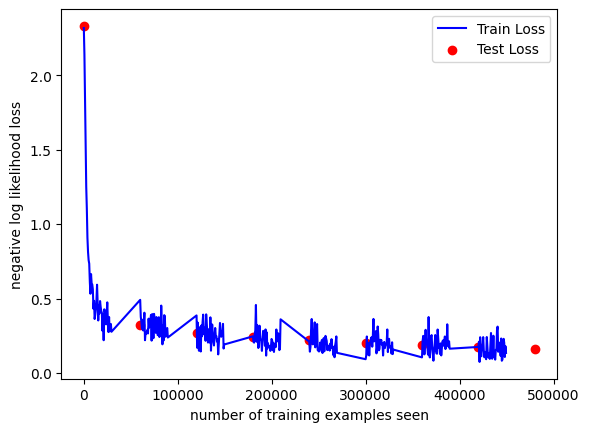

In [ ]:
fig = plt.figure()
plt.plot(train_counter, train_losses, color='blue')
plt.scatter(test_counter, test_losses, color='red')
plt.legend(['Train Loss', 'Test Loss'], loc='upper right')
plt.xlabel('number of training examples seen')
plt.ylabel('negative log likelihood loss')

도출된 손실 수렴 곡선(Loss convergence curve)을 시각화한 결과, 단일 세션에서 연속적으로 최적화를 수행한 것과 동일하게 궤적이 매끄럽게 이어짐을 확인하였다.

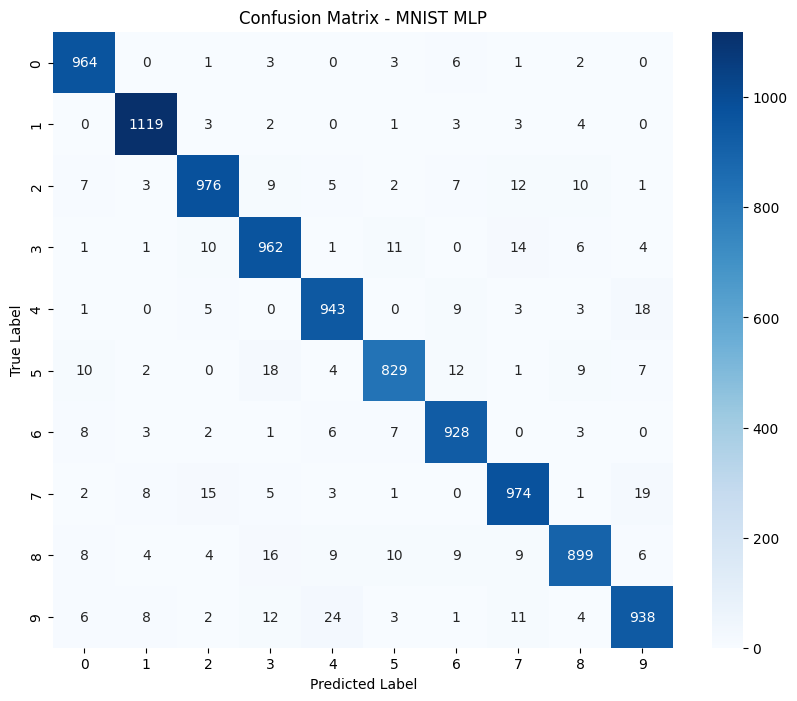

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd
import numpy as np

# 1. 테스트 데이터에 대해 예측 수행
network.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:
        output = network(data)
        pred = output.data.max(1, keepdim=True)[1]
        all_preds.extend(pred.view(-1).cpu().numpy())
        all_targets.extend(target.cpu().numpy())

# 2. 혼동 행렬 계산
cm = confusion_matrix(all_targets, all_preds)

# 3. 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - MNIST MLP')
plt.show()

### 혼동 행렬(Confusion Matrix) 해석

혼동 행렬은 분류 모델의 성능을 각 클래스별로 상세하게 보여주는 도구이다.

*   **세로축(True Label):** 실제 이미지의 숫자.
*   **가로축(Predicted Label):** 모델이 예측한 숫자.
*   **대각선(Diagonal elements):** 모델이 정답을 맞춘 경우. 숫자가 클수록 해당 클래스를 잘 분류하고 있음을 의미.
*   **대각선 외의 요소:** 모델이 숫자를 혼동한 경우. 예를 들어, (True: 4, Predicted: 9) 위치의 숫자가 크다면 모델이 4를 9로 자주 오해하고 있다는 뜻.

## 결과 요약
1. 체크포인트를 활용한 내부 상태 복원 및 학습 재개가 이론적 기댓값에 부합하게 작동하였다.
2. 제안하는 방법은 해당 훈련 구간 내에서 유의미한 과적합 징후를 보이지 않았다.
3. 종합적으로 PyTorch 및 TorchVision 프레임워크를 활용하여 MNIST 분류 목적의 환경을 구축하였다.

# 3. Neural Network 의 여러 파라미터를 변경하여 튜닝 진행해보기

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd
import numpy as np


#이하 모든 코드는 이전과 같음
def train_all(network, optimizer = optimizer, n_epochs = 3):

    train_losses = []
    train_counter = []
    test_losses = []
    test_counter = [i*len(train_loader.dataset) for i in range(n_epochs + 1)]

    test()
    for epoch in range(1, n_epochs + 1):
        train(epoch)
        test()
    with torch.no_grad():
        output = network(example_data)
    fig = plt.figure()
    for i in range(6):
        plt.subplot(2,3,i+1)
        plt.tight_layout()
        plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
        plt.title("Prediction: {}".format(
            output.data.max(1, keepdim=True)[1][i].item()))
        plt.xticks([])
        plt.yticks([])

    # 1. 테스트 데이터에 대해 예측 수행
    network.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for data, target in test_loader:
            output = network(data)
            pred = output.data.max(1, keepdim=True)[1]
            all_preds.extend(pred.view(-1).cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    # 2. 혼동 행렬 계산
    cm = confusion_matrix(all_targets, all_preds)

    # 3. 시각화
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix - MNIST MLP(SIGMOID)')
    plt.show()

이 섹션에서는 MLP에서 어떤 것이 커스터마이징이 가능하고, 어떻게 커스터마이징 하는 것이 좋은 지 알아본다.

위 코드는 전체 학습 과정을 한번에 출력하기 위해 앞서 했던 모든 작업을 묶어둔 것이다.

## 모델 구조 변경

### Layer 추가
두개의 layer 모델이 3개의 레이어를 가지도록 변경한다.

In [ ]:
class Custom_model(nn.Module):
    def __init__(self, input_size: int = 784, hidden_size: int = 100, hidden_size_2: int = 100, output_size: int = 10):
        super(Custom_model, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size_2) # 추가된 레이어, 앞의 레이어의 출력 뉴런의 개수와 현재 레이어의 입력 개수를 동일하게 맞춰야 한다. 현재 레이어의 출력 개수와 뒤의 레이어의 입력 개수 또한 동일하게 구성해야 한다.
        self.fc3 = nn.Linear(hidden_size_2, hidden_size_2)
        self.fc4 = nn.Linear(hidden_size_2, output_size)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x)) # 동작 과정 추가
        x = F.relu(self.fc3(x))
        x = self.fc4(x) # 출력 변경

        return x

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:3503: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  reduction = _Reduction.legacy_get_string(size_average, reduce)



Test set: Avg. loss: 2.3021, Accuracy: 698/10000 (7%)

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.305259
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.297103
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.285236
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.274424
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.273017
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.261918
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.245294
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.215280
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.208528
Train Epoch: 1 [11520/60000 (19%)]	Loss: 2.157981
Train Epoch: 1 [12800/60000 (21%)]	Loss: 2.140334
Train Epoch: 1 [14080/60000 (23%)]	Loss: 2.089557
Train Epoch: 1 [15360/60000 (26%)]	Loss: 1.982698
Train Epoch: 1 [16640/60000 (28%)]	Loss: 1.919819
Train Epoch: 1 [17920/60000 (30%)]	Loss: 1.828539
Train Epoch: 1 [19200/60000 (32%)]	Loss: 1.744116
Train Epoch: 1 [20480/60000 (34%)]	Loss: 1.590111
Train Epoch: 1 [21760/60000 (36%)]	Loss: 1.571606
Train Epoch: 1 [23040/60000 (38%)]	Loss: 1.444175
Train Epoc

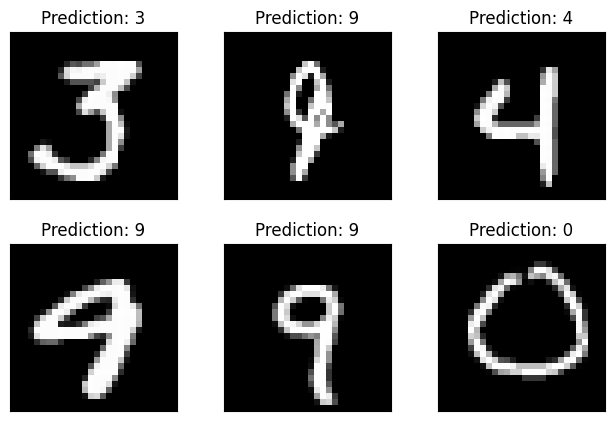

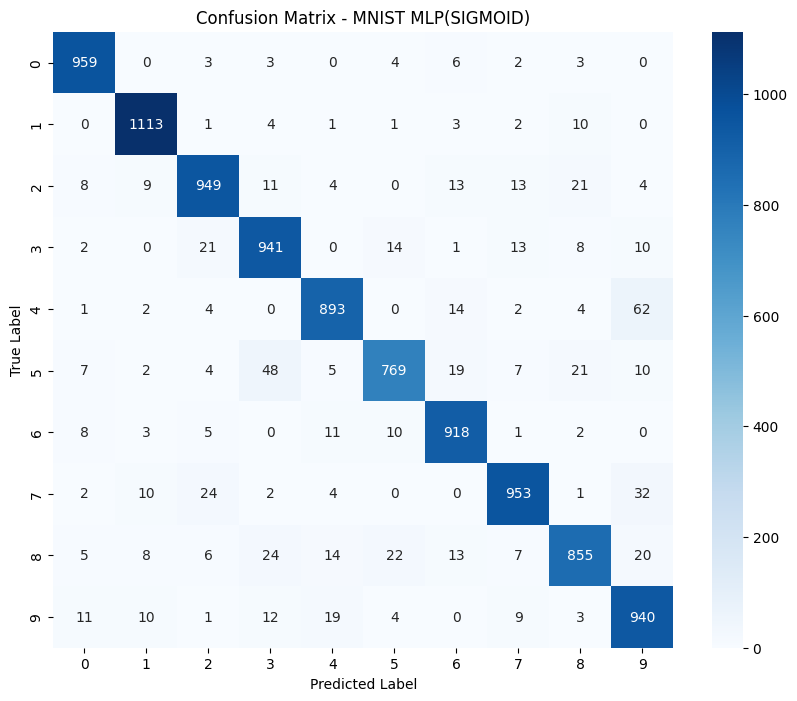

In [ ]:
network = Custom_model() # 이때 위의 만든 모델의 이름으로 변경이 필요하다.
optimizer = optim.SGD(network.parameters(), lr=learning_rate, momentum=momentum) # optimizer 구성
train_all(network, optimizer)

Q. 학습 결과가 좋아졌는지 확인하기

### Parameter 추가
두개의 layer 모델 내부 hidden 차원 수를 변경해본다.

첫번째 방법

In [ ]:
class Custom_model(nn.Module):
    def __init__(self, input_size: int = 784, hidden_size: int = 50, output_size: int = 10):
        super(Custom_model, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:3503: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  reduction = _Reduction.legacy_get_string(size_average, reduce)



Test set: Avg. loss: 2.3338, Accuracy: 957/10000 (10%)

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.359732
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.011289
Train Epoch: 1 [2560/60000 (4%)]	Loss: 1.725424
Train Epoch: 1 [3840/60000 (6%)]	Loss: 1.412359
Train Epoch: 1 [5120/60000 (9%)]	Loss: 1.191672
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.001640
Train Epoch: 1 [7680/60000 (13%)]	Loss: 0.873640
Train Epoch: 1 [8960/60000 (15%)]	Loss: 0.842722
Train Epoch: 1 [10240/60000 (17%)]	Loss: 0.756132
Train Epoch: 1 [11520/60000 (19%)]	Loss: 0.686482
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.674986
Train Epoch: 1 [14080/60000 (23%)]	Loss: 0.545664
Train Epoch: 1 [15360/60000 (26%)]	Loss: 0.606175
Train Epoch: 1 [16640/60000 (28%)]	Loss: 0.489537
Train Epoch: 1 [17920/60000 (30%)]	Loss: 0.604766
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.510250
Train Epoch: 1 [20480/60000 (34%)]	Loss: 0.447868
Train Epoch: 1 [21760/60000 (36%)]	Loss: 0.450662
Train Epoch: 1 [23040/60000 (38%)]	Loss: 0.351419
Train Epo

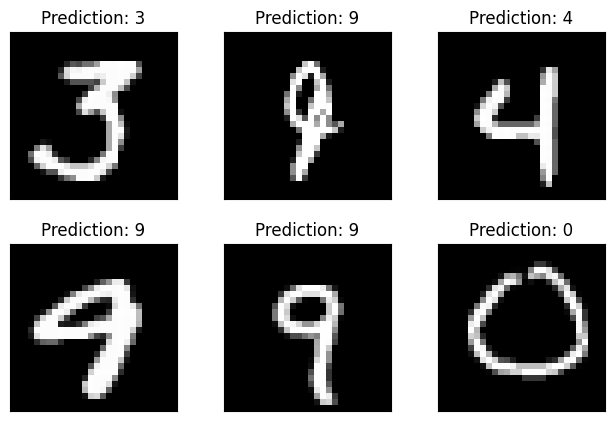

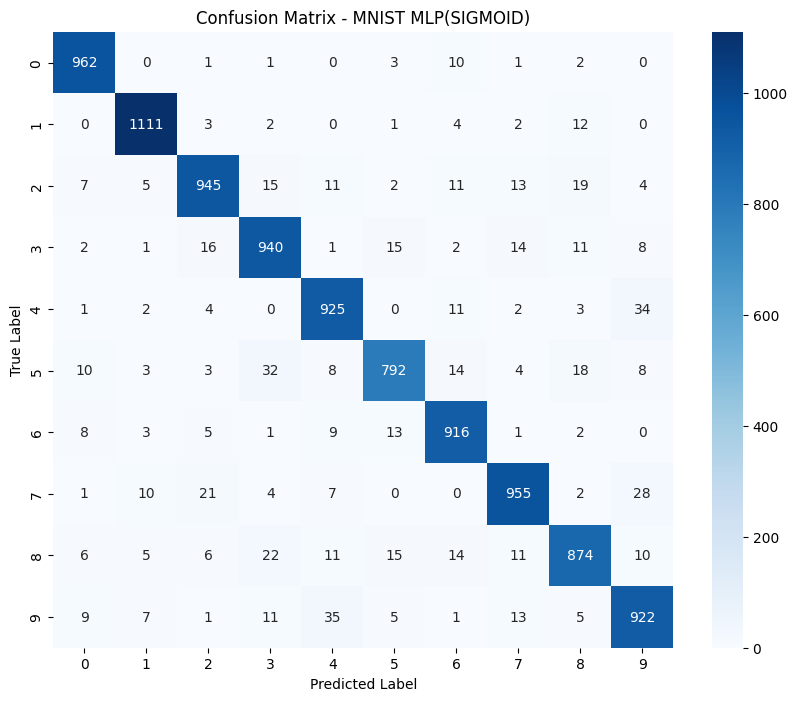

In [ ]:
network = Custom_model(hidden_size = 200) # 모델 생성 시에 hidden size 를 변수로 넣어주기, Default = 100
optimizer = optim.SGD(network.parameters(), lr=learning_rate, momentum=momentum)
train_all(network, optimizer)

두번째 방법

In [ ]:
class Custom_model(nn.Module): # 직접 값을 바꿔주기, 추천하지 않음
    def __init__(self):
        super(Custom_model, self).__init__()
        self.fc1 = nn.Linear(784, 150)
        self.fc2 = nn.Linear(150, 10)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

### Activation 함수 변경해보기

딥러닝 네트워크는 이렇게 설계된 뉴런들을 연결하여 입력층, 은닉층, 출력층을 구성하고 각각의 가중치를 자동으로 학습하게 된다.

활성화 함수를 변경하여 모델을 학습시키고 그 결과를 확인해본다.

활성화 함수의 모양새만 다를 뿐 같은 역할을 수행한다.

더 많은 activation: [Torch non-linear activation](https://https://docs.pytorch.org/docs/stable/nn.functional.html#non-linear-activation-functions)


#### 대표 예시 1. 시그모이드 (Sigmoid) 함수

로지스틱(Logistic) 함수라고도 불리며 비선형 값을 얻지 못하는 퍼셉트론 함수의 한계를 극복하기 위해 사용하기 시작하였다.

시그모이드 함수는 다음과 같이 구성된다.

    σ(x) = 1/ 1+e^(−x)
    σ'(x)=σ(x)(1−σ(x))

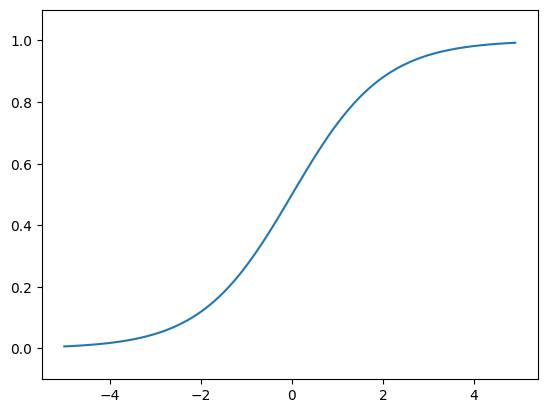

In [ ]:
def sigmoid(x):
    # 수치적 안정성을 위해 np.clip을 사용하거나 지수 함수 계산 순서를 조정할 수 있습니다.
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))

x = np.arange(-5.0, 5.0, 0.1)
y = sigmoid(x)

# 그래프작성
plt.plot(x,y) # x,y로 그래프 생성
plt.ylim(-0.1, 1.1) # y축 범위 지정
plt.show()

In [ ]:
class Custom_model(nn.Module):
    def __init__(self, input_size: int = 784, hidden_size: int = 100, output_size: int = 10):
        super(Custom_model, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)
        x = F.sigmoid(self.fc1(x)) # Activation 함수 변경 (relu -> sigmoid)
        x = self.fc2(x)

        return x

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:3503: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  reduction = _Reduction.legacy_get_string(size_average, reduce)



Test set: Avg. loss: 2.3346, Accuracy: 1011/10000 (10%)

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.332259
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.246860
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.219958
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.180304
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.147241
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.108683
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.015792
Train Epoch: 1 [8960/60000 (15%)]	Loss: 1.980139
Train Epoch: 1 [10240/60000 (17%)]	Loss: 1.975153
Train Epoch: 1 [11520/60000 (19%)]	Loss: 1.948678
Train Epoch: 1 [12800/60000 (21%)]	Loss: 1.889546
Train Epoch: 1 [14080/60000 (23%)]	Loss: 1.845747
Train Epoch: 1 [15360/60000 (26%)]	Loss: 1.808399
Train Epoch: 1 [16640/60000 (28%)]	Loss: 1.768916
Train Epoch: 1 [17920/60000 (30%)]	Loss: 1.727323
Train Epoch: 1 [19200/60000 (32%)]	Loss: 1.591881
Train Epoch: 1 [20480/60000 (34%)]	Loss: 1.592460
Train Epoch: 1 [21760/60000 (36%)]	Loss: 1.568407
Train Epoch: 1 [23040/60000 (38%)]	Loss: 1.541115
Train Ep

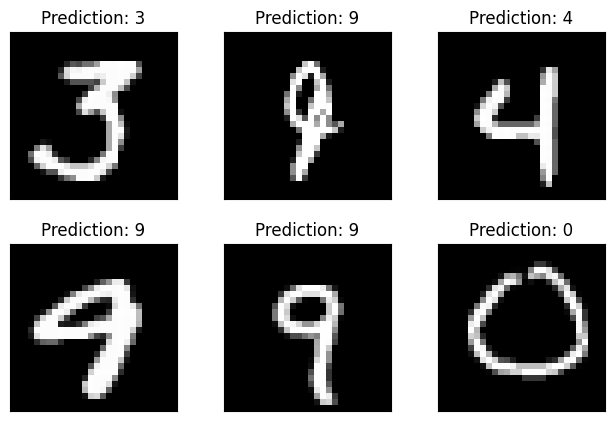

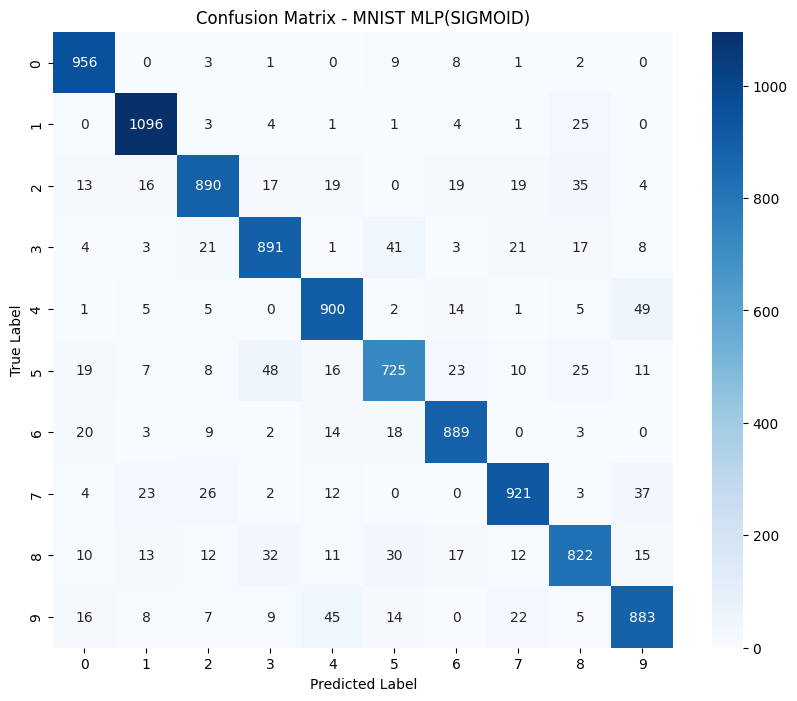

In [ ]:
network = Custom_model()
optimizer = optim.SGD(network.parameters(), lr=learning_rate, momentum=momentum)
train_all(network, optimizer)

#### 대표 예시 2.렐루 (ReLU) 함수

시그모이드 함수처럼 긴 시간이 지나면 활성화 함수의 값이 0이 되는 문제를 해결하기 위해 나온 함수이다.

입력이 양수일때는 기울기가 1인 출력을(x=y), 음수 일때는 기울기를 0인(y=0) 출력을 갖는다.

    y = x if x>0
    y = 0 if x<=0    
    
렐루 함수는 연산 비용이 크지 않고 구현이 쉬우며, 학습이 다른 활성화 함수에 비해 빠른 장점을 가진다.

이외에도 입력이 음수일때 기울기가 0이기 때문에 뉴럴이 죽는 문제를 해결하기 위해 다양한 개량형 렐루 함수가 있다.

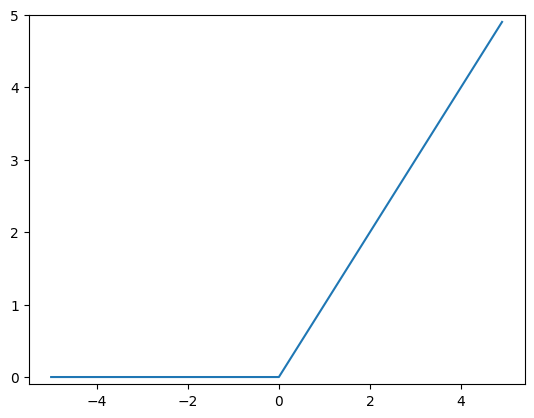

In [ ]:
# ReLU 함수 구현
# ReLU 함수는 입력이 0을 넘으면 그대로 출력하고, 0 이하면 0을 출력하는 함수이다.
def relu(x):
    return np.maximum(0, x) # 넘파이 maximum 메서드를 사용하여 간단하게 구현 가능하다.

x = np.arange(-5.0, 5.0, 0.1)
y = relu(x)

# 그래프작성
plt.plot(x,y) # x,y로 그래프 생성
plt.ylim(-0.1, 5) # y축 범위 지정
plt.show()

In [ ]:
class Custom_model(nn.Module):
    def __init__(self, input_size: int = 784, hidden_size: int = 100, output_size: int = 10):
        super(Custom_model, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x)) # Activation 함수 변경 (relu -> sigmoid)
        x = self.fc2(x)

        return x

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:3503: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  reduction = _Reduction.legacy_get_string(size_average, reduce)



Test set: Avg. loss: 2.3065, Accuracy: 1716/10000 (17%)

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.308702
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.258109
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.230451
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.158941
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.120072
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.075256
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.033824
Train Epoch: 1 [8960/60000 (15%)]	Loss: 1.982999
Train Epoch: 1 [10240/60000 (17%)]	Loss: 1.923312
Train Epoch: 1 [11520/60000 (19%)]	Loss: 1.868502
Train Epoch: 1 [12800/60000 (21%)]	Loss: 1.855449
Train Epoch: 1 [14080/60000 (23%)]	Loss: 1.792954
Train Epoch: 1 [15360/60000 (26%)]	Loss: 1.776293
Train Epoch: 1 [16640/60000 (28%)]	Loss: 1.697498
Train Epoch: 1 [17920/60000 (30%)]	Loss: 1.662864
Train Epoch: 1 [19200/60000 (32%)]	Loss: 1.657375
Train Epoch: 1 [20480/60000 (34%)]	Loss: 1.585703
Train Epoch: 1 [21760/60000 (36%)]	Loss: 1.526581
Train Epoch: 1 [23040/60000 (38%)]	Loss: 1.538691
Train Ep

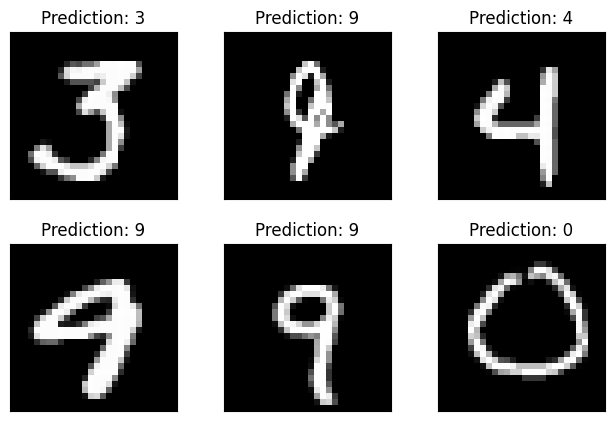

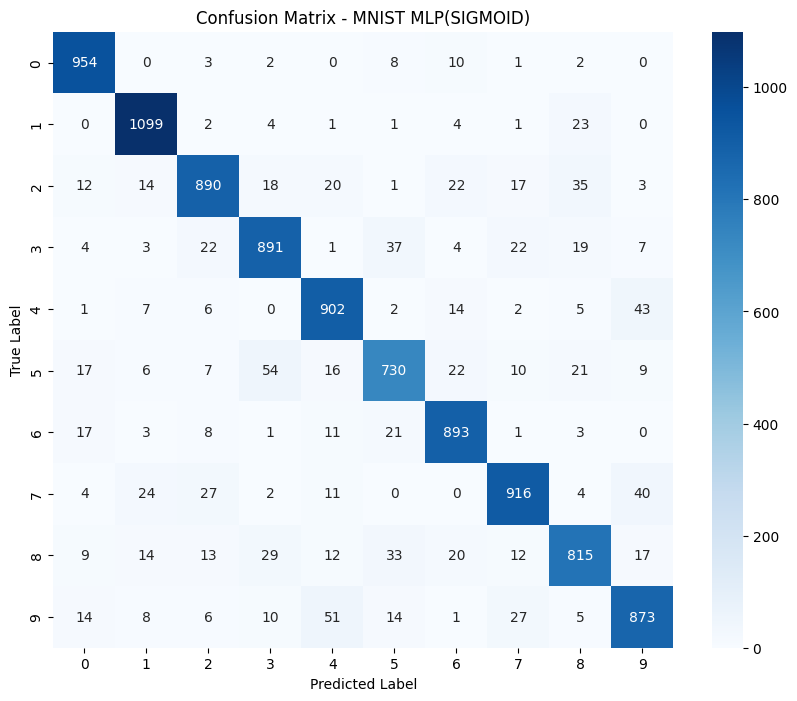

In [ ]:
network = Custom_model()
optimizer = optim.SGD(network.parameters(), lr=learning_rate, momentum=momentum)
train_all(network, optimizer)

## 학습 방법 변경

 모델 구조 이외에도 다양한 학습 환경 변경 방법이 존재한다.

 1. optimizer 변경 -> 학습 시 사용되는 optimizer 자체를 변경하거나, optimizer에 들어가는 입력 변수를 변경하기
 2. 데이터 loader 변경 -> 학습 횟수, batch 등 다양한 학습 변수 조정하기

### Optimizer 및 Optimizer 파라미터 변경하기

optimizer는 학습 시 모델이 어느 방향으로 학습해야 하는지, 또 얼마만큼 학습해야 loss 를 감소시킬 수 있는 지를 정한다.

학습 방향과 학습량을 조절하여 모델의 성능을 최적화하는 핵심적인 역할을 수행한다.

더 많은 optimizer: [Torch non-linear activation](https://docs.pytorch.org/docs/stable/optim.html)


/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:3503: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  reduction = _Reduction.legacy_get_string(size_average, reduce)



Test set: Avg. loss: 2.3287, Accuracy: 1113/10000 (11%)

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.310775
Train Epoch: 1 [1280/60000 (2%)]	Loss: 0.812036
Train Epoch: 1 [2560/60000 (4%)]	Loss: 0.487151
Train Epoch: 1 [3840/60000 (6%)]	Loss: 0.263199
Train Epoch: 1 [5120/60000 (9%)]	Loss: 0.311567
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.212769
Train Epoch: 1 [7680/60000 (13%)]	Loss: 0.290373
Train Epoch: 1 [8960/60000 (15%)]	Loss: 0.367276
Train Epoch: 1 [10240/60000 (17%)]	Loss: 0.297060
Train Epoch: 1 [11520/60000 (19%)]	Loss: 0.415091
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.215162
Train Epoch: 1 [14080/60000 (23%)]	Loss: 0.165401
Train Epoch: 1 [15360/60000 (26%)]	Loss: 0.273858
Train Epoch: 1 [16640/60000 (28%)]	Loss: 0.209011
Train Epoch: 1 [17920/60000 (30%)]	Loss: 0.259028
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.223144
Train Epoch: 1 [20480/60000 (34%)]	Loss: 0.173691
Train Epoch: 1 [21760/60000 (36%)]	Loss: 0.238619
Train Epoch: 1 [23040/60000 (38%)]	Loss: 0.274643
Train Ep

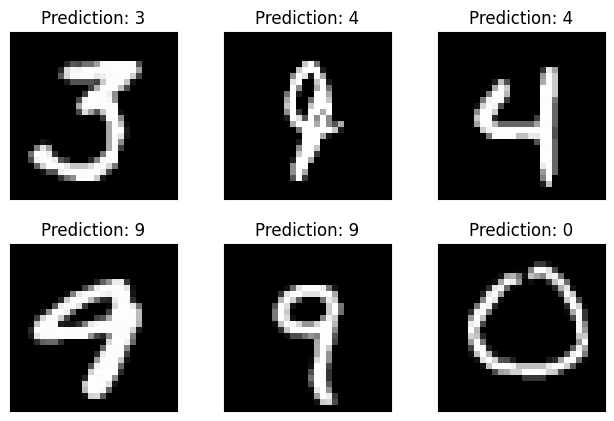

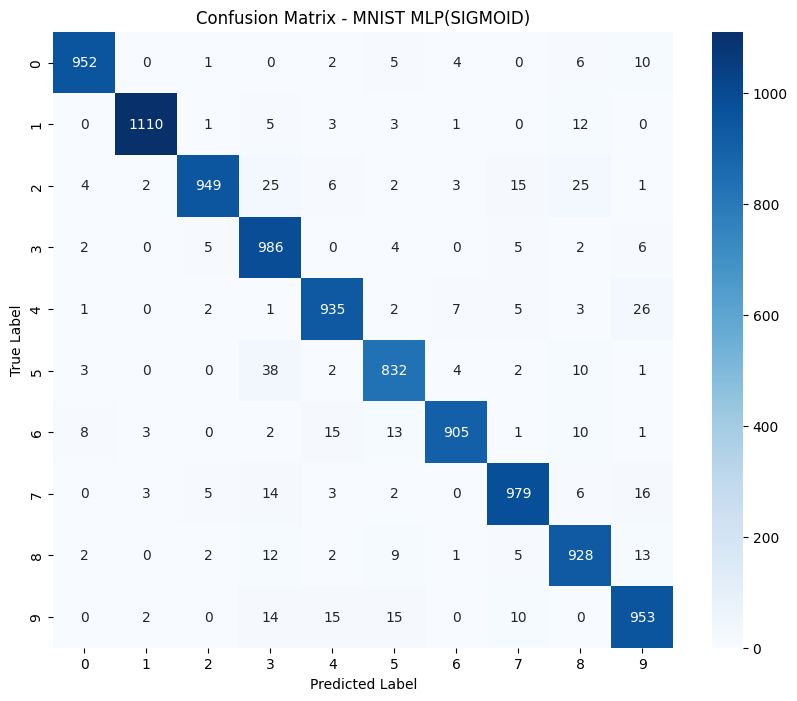

In [ ]:
network = Custom_model()
optimizer = optim.Adam(network.parameters(), lr=learning_rate) # optimizer 를 SGD 에서 Adam으로 변경
train_all(network, optimizer)

Q. optimizer에 들어가는 두가지의 파라미터 (learning rate, 그리고 momentum을 변동시켜서 얼마나 학습이 진행되는 지 확인하기.

### Data 반복 횟수 늘려보기

In [ ]:
network = Custom_model()
optimizer = optim.Adam(network.parameters(), lr=learning_rate) # optimizer 를 SGD 에서 Adam으로 변경
train_all(network, optimizer, n_epochs = 10)

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:3503: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  reduction = _Reduction.legacy_get_string(size_average, reduce)



Test set: Avg. loss: 2.3296, Accuracy: 954/10000 (10%)

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.364779
Train Epoch: 1 [1280/60000 (2%)]	Loss: 1.099611
Train Epoch: 1 [2560/60000 (4%)]	Loss: 0.586698
Train Epoch: 1 [3840/60000 (6%)]	Loss: 0.429300
Train Epoch: 1 [5120/60000 (9%)]	Loss: 0.438687
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.347770
Train Epoch: 1 [7680/60000 (13%)]	Loss: 0.317595
Train Epoch: 1 [8960/60000 (15%)]	Loss: 0.309019
Train Epoch: 1 [10240/60000 (17%)]	Loss: 0.357550
Train Epoch: 1 [11520/60000 (19%)]	Loss: 0.235512
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.298189
Train Epoch: 1 [14080/60000 (23%)]	Loss: 0.221416
Train Epoch: 1 [15360/60000 (26%)]	Loss: 0.315833
Train Epoch: 1 [16640/60000 (28%)]	Loss: 0.242346
Train Epoch: 1 [17920/60000 (30%)]	Loss: 0.205823
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.323991
Train Epoch: 1 [20480/60000 (34%)]	Loss: 0.190868
Train Epoch: 1 [21760/60000 (36%)]	Loss: 0.199027
Train Epoch: 1 [23040/60000 (38%)]	Loss: 0.225270
Train Epo

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:3503: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  reduction = _Reduction.legacy_get_string(size_average, reduce)



Test set: Avg. loss: 0.1272, Accuracy: 9644/10000 (96%)

Train Epoch: 36 [0/60000 (0%)]	Loss: 0.061890
Train Epoch: 36 [1280/60000 (2%)]	Loss: 0.099406
Train Epoch: 36 [2560/60000 (4%)]	Loss: 0.042825
Train Epoch: 36 [3840/60000 (6%)]	Loss: 0.036220
Train Epoch: 36 [5120/60000 (9%)]	Loss: 0.021689
Train Epoch: 36 [6400/60000 (11%)]	Loss: 0.042751
Train Epoch: 36 [7680/60000 (13%)]	Loss: 0.014128
Train Epoch: 36 [8960/60000 (15%)]	Loss: 0.088110
Train Epoch: 36 [10240/60000 (17%)]	Loss: 0.031235
Train Epoch: 36 [11520/60000 (19%)]	Loss: 0.137307
Train Epoch: 36 [12800/60000 (21%)]	Loss: 0.031833
Train Epoch: 36 [14080/60000 (23%)]	Loss: 0.083617
Train Epoch: 36 [15360/60000 (26%)]	Loss: 0.036364
Train Epoch: 36 [16640/60000 (28%)]	Loss: 0.087931
Train Epoch: 36 [17920/60000 (30%)]	Loss: 0.126924
Train Epoch: 36 [19200/60000 (32%)]	Loss: 0.103654
Train Epoch: 36 [20480/60000 (34%)]	Loss: 0.085588
Train Epoch: 36 [21760/60000 (36%)]	Loss: 0.076888
Train Epoch: 36 [23040/60000 (38%)]	Loss

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:3503: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  reduction = _Reduction.legacy_get_string(size_average, reduce)



Test set: Avg. loss: 0.1208, Accuracy: 9660/10000 (97%)

Train Epoch: 37 [0/60000 (0%)]	Loss: 0.119673
Train Epoch: 37 [1280/60000 (2%)]	Loss: 0.145481
Train Epoch: 37 [2560/60000 (4%)]	Loss: 0.040334
Train Epoch: 37 [3840/60000 (6%)]	Loss: 0.018582
Train Epoch: 37 [5120/60000 (9%)]	Loss: 0.135021
Train Epoch: 37 [6400/60000 (11%)]	Loss: 0.059269
Train Epoch: 37 [7680/60000 (13%)]	Loss: 0.125451
Train Epoch: 37 [8960/60000 (15%)]	Loss: 0.141811
Train Epoch: 37 [10240/60000 (17%)]	Loss: 0.078002
Train Epoch: 37 [11520/60000 (19%)]	Loss: 0.061268
Train Epoch: 37 [12800/60000 (21%)]	Loss: 0.032874
Train Epoch: 37 [14080/60000 (23%)]	Loss: 0.026552
Train Epoch: 37 [15360/60000 (26%)]	Loss: 0.011910
Train Epoch: 37 [16640/60000 (28%)]	Loss: 0.052573
Train Epoch: 37 [17920/60000 (30%)]	Loss: 0.045171
Train Epoch: 37 [19200/60000 (32%)]	Loss: 0.023592
Train Epoch: 37 [20480/60000 (34%)]	Loss: 0.071875
Train Epoch: 37 [21760/60000 (36%)]	Loss: 0.139374
Train Epoch: 37 [23040/60000 (38%)]	Loss

KeyboardInterrupt: 

## 손실 함수 (Loss function)

뉴럴 네트워크는 학습을 통해 최적의 가중치를 구하기 위한 지표로 손실 함수를 사용한다.

네트워크 학습의 최종 목표는 손실함수의 결과(오차)값을 최소화 하는 것이며, 이를 위해 가중치를 조작해나가게 된다.



# 4. MLP를 통해 회귀(Regression) 모델 만들어보기

이전 세션에서는 이산적인 클래스 라벨을 예측하는 분류(Classification) 문제를 다루었다.

본 세션에서는 연속적인 실수 값을 예측하는 회귀(Regression) 문제를 풀어본다.

## 손실 함수의 차이점

classification 문제에서는 이미지가 0부터 9까지의 label 중 어떤 label을 가질 지 확률 값으로 출력한다. (ex. 이미지가 0일 확률 0.1%, 1일 확률 2%, 2일 확률 96%, ..., 9일 확률 0.5%)

그렇기 때문에 모델의 출력 output은 총 10개(output size 만큼) 이 되어야 각 label에 할당된 확률값이 나오게 된다.

그러나, 회귀에서는 특정 값의 확률 예측이 아닌 실제 값 하나를 예측해야 하므로 이러한 전략 수행이 어렵다.

이를 loss 함수로 확인해본다.


### 교차 엔트로피 오차 (CEE),주로 Classification에 사용됨.

자연로그를 사용하는 오차산출방법. 정답일때의 출력이 전체 값을 정하게 되며 작을 수록 정답에 가깝다.

In [ ]:
import numpy as np

In [ ]:
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    # 원-핫 인코딩 정답 레이블 처리
    if t.size == y.size:
        t = t.argmax(axis=1)

    batch_size = y.shape[0]
    # y + 1e-7 로 log(0) 방지
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size

In [ ]:
y1 = np.array([0.1,0.05,0.6,0.0,0.05,0.1,0.0,0.1,0.0,0.0]) # 2로 추정
y2 = np.array([0.1,0.05,0.1,0.0,0.05,0.1,0.0,0.6,0.0,0.0]) # 7로 추정
t = np.array([0,0,1,0,0,0,0,0,0,0]) # 정답 2 (원-핫 인코딩)

print(f"cross_entropy_error for y1 (predicting 2): {cross_entropy_error(y1, t)}")
print(f"cross_entropy_error for y2 (predicting 7): {cross_entropy_error(y2, t)}")

cross_entropy_error for y1 (predicting 2): 0.510825457099338
cross_entropy_error for y2 (predicting 7): 2.302584092994546


In [ ]:
y1=np.array([128,100])
y2=np.array([250,150])

t=np.array([150,100]) # 정답 150,100
print(f"cross_entropy_error for y1 : {cross_entropy_error(y1, t)}") # 이때 추정 오차값이 낮을수록 정답에 가깝다
print(f"cross_entropy_error for y2 : {cross_entropy_error(y2, t)}") # 이때 추정 오차값이 낮을수록 정답에 가깝다

cross_entropy_error for y1 : -4.8520302647008675
cross_entropy_error for y2 : -5.521460918262246


### 평균 제곱 오차 (MSE)

평균의 제곱을 사용한 손실함수로 가장 기본적인 방법이다.

In [ ]:
def MSE(y, t):
    return 0.5*np.sum((y-t)**2)

In [ ]:
y1 = np.array([0.1,0.05,0.6,0.0,0.05,0.1,0.0,0.1,0.0,0.0])
y2 = np.array([0.1,0.05,0.1,0.0,0.05,0.1,0.0,0.6,0.0,0.0])
t = np.array([0,0,1,0,0,0,0,0,0,0])

print(f"MSE for y1 : {MSE(y1, t)}")
print(f"MSE for y2 : {MSE(y2, t)}")

MSE for y1 : 0.09750000000000003
MSE for y2 : 0.5975


In [ ]:
y1=[128]
y2=[250]

t=[150] # 정답 150
print(MSE(np.array(y1),np.array(t))) # 이때 추정 오차값이 낮을수록 정답에 가깝다
print(MSE(np.array(y2),np.array(t)))

242.0
5000.0


위와 같이 각 loss 함수 마다 사용하는 방법이나 메카니즘의 차이가 존재하여 classification 문제인지, 아니면 regression 문제인지에 따라 다른 loss 를 사용하게 된다.

## 데이터셋 설명 및 상관관계(Correlation) 분석

이번 세션에서는 캘리포니아 주택 가격 데이터셋을 사용한다.

위도, 경도, 소득 등 8개의 특성(Feature)을 기반으로 주택 가격(Target)을 예측한다.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# 1. 데이터 로드
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['Target_Price'] = california.target

In [ ]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target_Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


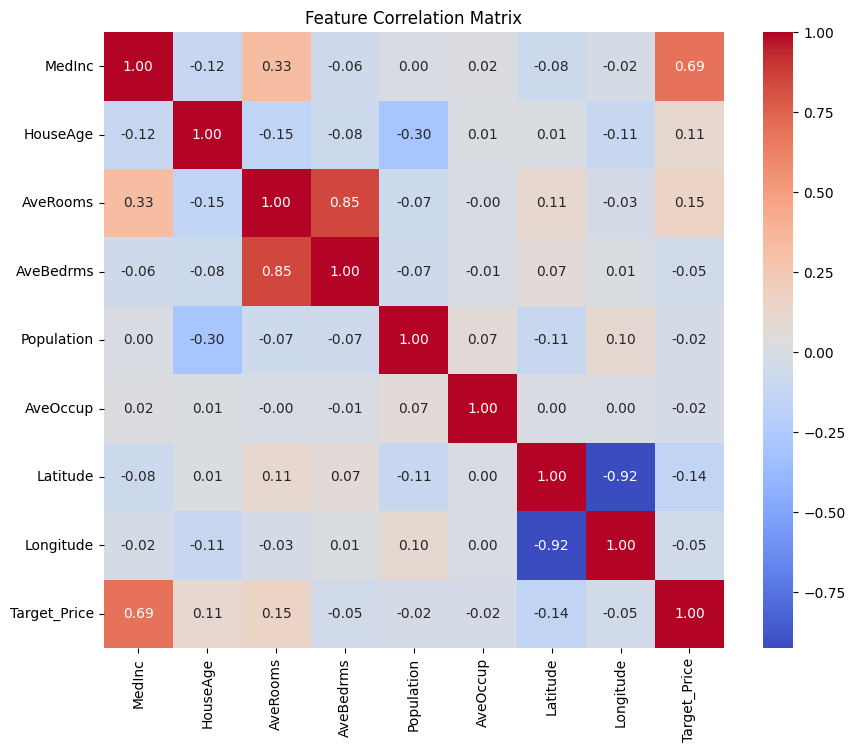

In [ ]:
# 2. 데이터 시각화 및 상관관계 확인
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

가격과 다른 지표들의 상관관계로 MedInc(중위 소득) 변수가 Target_Price와 가장 높은 양의 상관관계를 가짐을 확인 할 수 있다.

## 회귀 모델의 출력층 구조 및 손실 함수(Loss Function)

분류 문제에서는 각 클래스에 대한 확률분포를 출력하기 위해 노드 수가 클래스 개수와 동일했으며, Softmax 활성화 함수와 교차 엔트로피 오차($\mathcal{L}_{CE}$)를 사용했다.


반면 회귀 문제에서는 단일 연속값을 예측하므로 다음 규칙을 적용한다.

1. Output Node 수: 1개. 최종 예측값이 스칼라(Scalar) 형태이기 때문임.

2. Output Activation: 없음(Linear). 값의 범위에 제한을 두지 않아야 함.

3. Loss Function: 평균 제곱 오차(Mean Squared Error, MSE).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import TensorDataset, DataLoader

# 1. 스케일링 및 분할 (딥러닝에서 입력 변수의 스케일 차이는 Gradient Vanishing/Exploding을 유발함)
X = df.drop('Target_Price', axis=1).values
y = df['Target_Price'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 데이터 분할

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. PyTorch Tensor 변환
# 주의: Regression의 target은 (N, 1) 차원을 가져야 loss 연산 시 broadcasting 오류가 발생하지 않음
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test).view(-1, 1)

# 3. DataLoader 구성 (기존 Classification 코드와 동일한 구조)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # batch size 64 고정
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## 회귀 모델 구조(MLP)

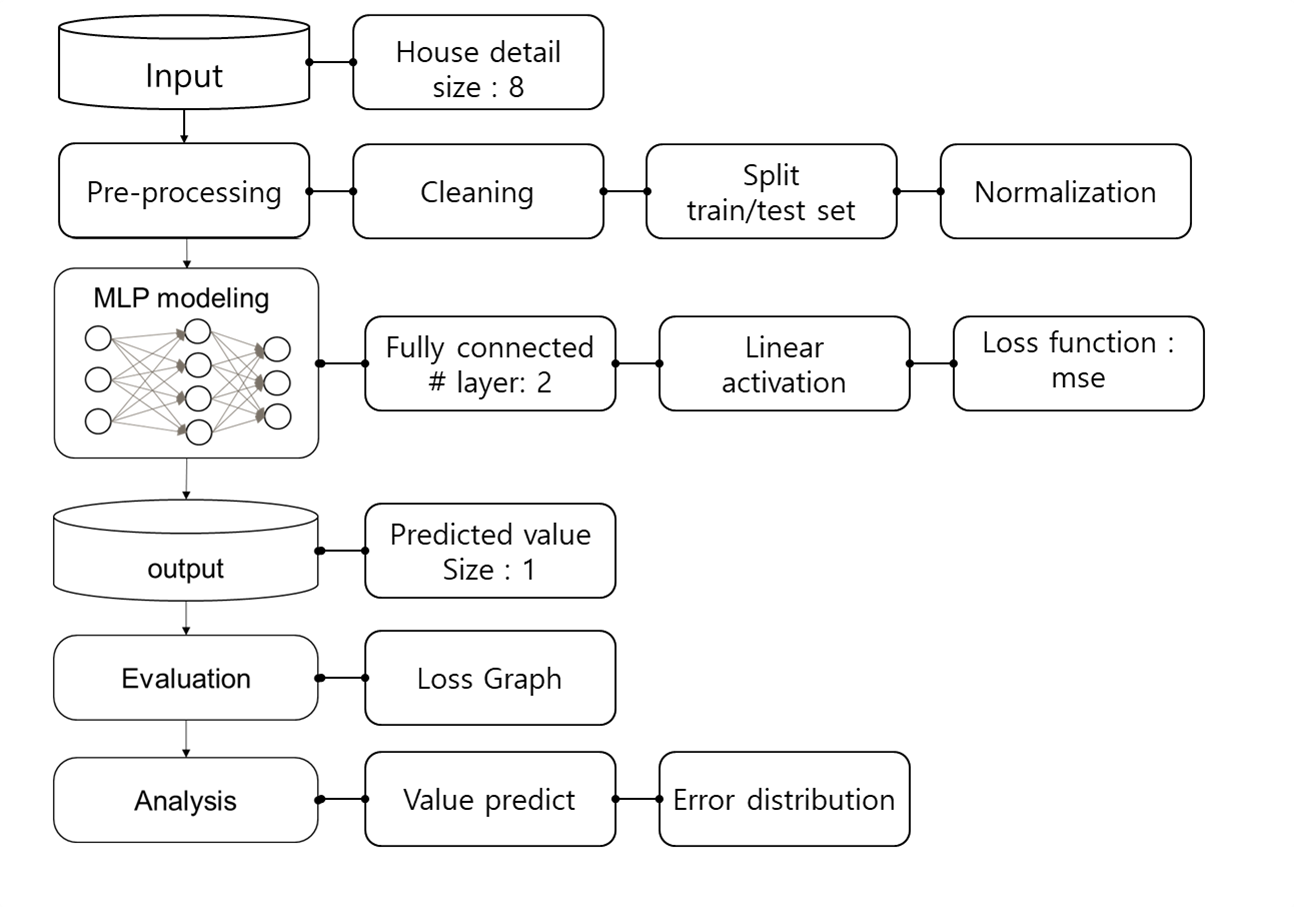

기존 분류 모델의 구조를 재사용하되, fc_out의 크기와 손실 함수(nn.MSELoss())를 회귀 도메인에 맞게 변형

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class RegressionMLP(nn.Module):
    def __init__(self, input_dim):
        super(RegressionMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        # Output layer: 1 dimension, NO activation function
        self.fc_out = nn.Linear(64, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc_out(x) # 예측값을 직접 반환
        return x

In [ ]:
# 모델 초기화
input_dim = X_train.shape[1] # 8 features
model = RegressionMLP(input_dim)

# 손실 함수 및 최적화 기법 정의 (MSE 사용)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 훈련 루프 (기존 방식과 동일하므로 간략화하여 실행)
epochs = 20
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch+1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], MSE Loss: {total_loss/len(train_loader):.4f}')

Epoch [5/20], MSE Loss: 0.3511
Epoch [10/20], MSE Loss: 0.3082
Epoch [15/20], MSE Loss: 0.2901
Epoch [20/20], MSE Loss: 0.2795


<>:41: SyntaxWarning: invalid escape sequence '\h'
<>:42: SyntaxWarning: invalid escape sequence '\h'
<>:49: SyntaxWarning: invalid escape sequence '\h'
<>:41: SyntaxWarning: invalid escape sequence '\h'
<>:42: SyntaxWarning: invalid escape sequence '\h'
<>:49: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1933/2830985855.py:41: SyntaxWarning: invalid escape sequence '\h'
  axes[0].set_ylabel('Predicted Value ($\hat{y}$)')
/tmp/ipykernel_1933/2830985855.py:42: SyntaxWarning: invalid escape sequence '\h'
  axes[0].set_title('Prediction Correlation ($y$ vs $\hat{y}$)')
/tmp/ipykernel_1933/2830985855.py:49: SyntaxWarning: invalid escape sequence '\h'
  axes[1].set_xlabel('Residuals ($y - \hat{y}$)')


[Test Performance]
RMSE: 0.5362
MAE: 0.3672
R^2 Score: 0.7806


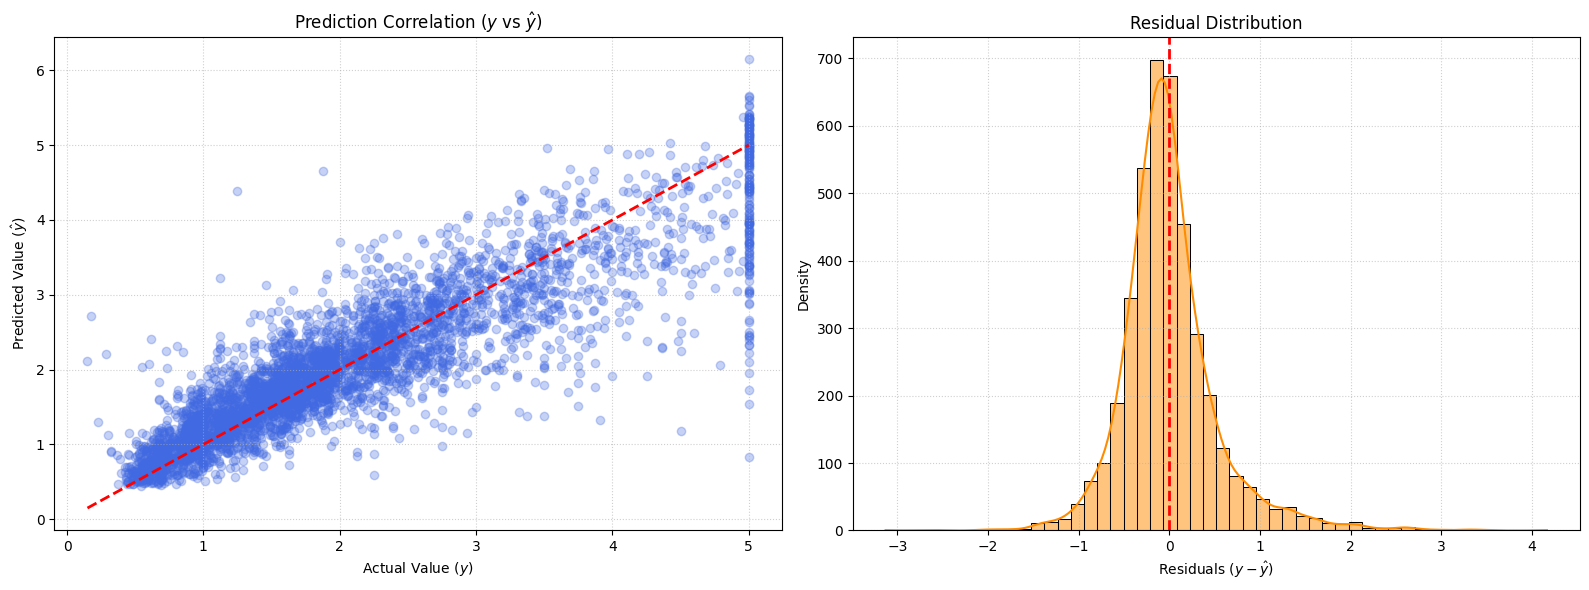

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 1. 모델 평가 모드 전환 (Dropout, BatchNorm 등의 동작 비활성화)
model.eval()

predictions_list = []
actuals_list = []

# Gradient 연산 비활성화 (메모리 사용량 감소 및 연산 속도 향상)
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        preds = model(batch_X)
        predictions_list.extend(preds.numpy())
        actuals_list.extend(batch_y.numpy())

# 2. 1차원 배열로 변환 (지표 계산 및 시각화를 위함)
predictions_np = np.array(predictions_list).flatten()
actuals_np = np.array(actuals_list).flatten()

# 3. 정량적 평가 지표 산출
rmse = np.sqrt(mean_squared_error(actuals_np, predictions_np))
mae = mean_absolute_error(actuals_np, predictions_np)
r2 = r2_score(actuals_np, predictions_np)

print(f"[Test Performance]")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

# 4. 성능 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 시각화 1: 실제값(Actual) vs 예측값(Predicted) 산점도
axes[0].scatter(actuals_np, predictions_np, alpha=0.3, color='royalblue')
# 완벽한 예측을 의미하는 y = x 기준선 (붉은 점선)
axes[0].plot([actuals_np.min(), actuals_np.max()], [actuals_np.min(), actuals_np.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Value ($y$)')
axes[0].set_ylabel('Predicted Value ($\hat{y}$)')
axes[0].set_title('Prediction Correlation ($y$ vs $\hat{y}$)')
axes[0].grid(True, linestyle=':', alpha=0.6)

# 시각화 2: 잔차(Residual) 분포 히스토그램
residuals = actuals_np - predictions_np
sns.histplot(residuals, kde=True, ax=axes[1], color='darkorange', bins=50)
axes[1].axvline(x=0, color='r', linestyle='--', lw=2) # 이상적인 잔차 중심
axes[1].set_xlabel('Residuals ($y - \hat{y}$)')
axes[1].set_ylabel('Density')
axes[1].set_title('Residual Distribution')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1933/2463697672.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eval, x='Quantile', y='Absolute_Error', ax=axes[2], palette='Reds')


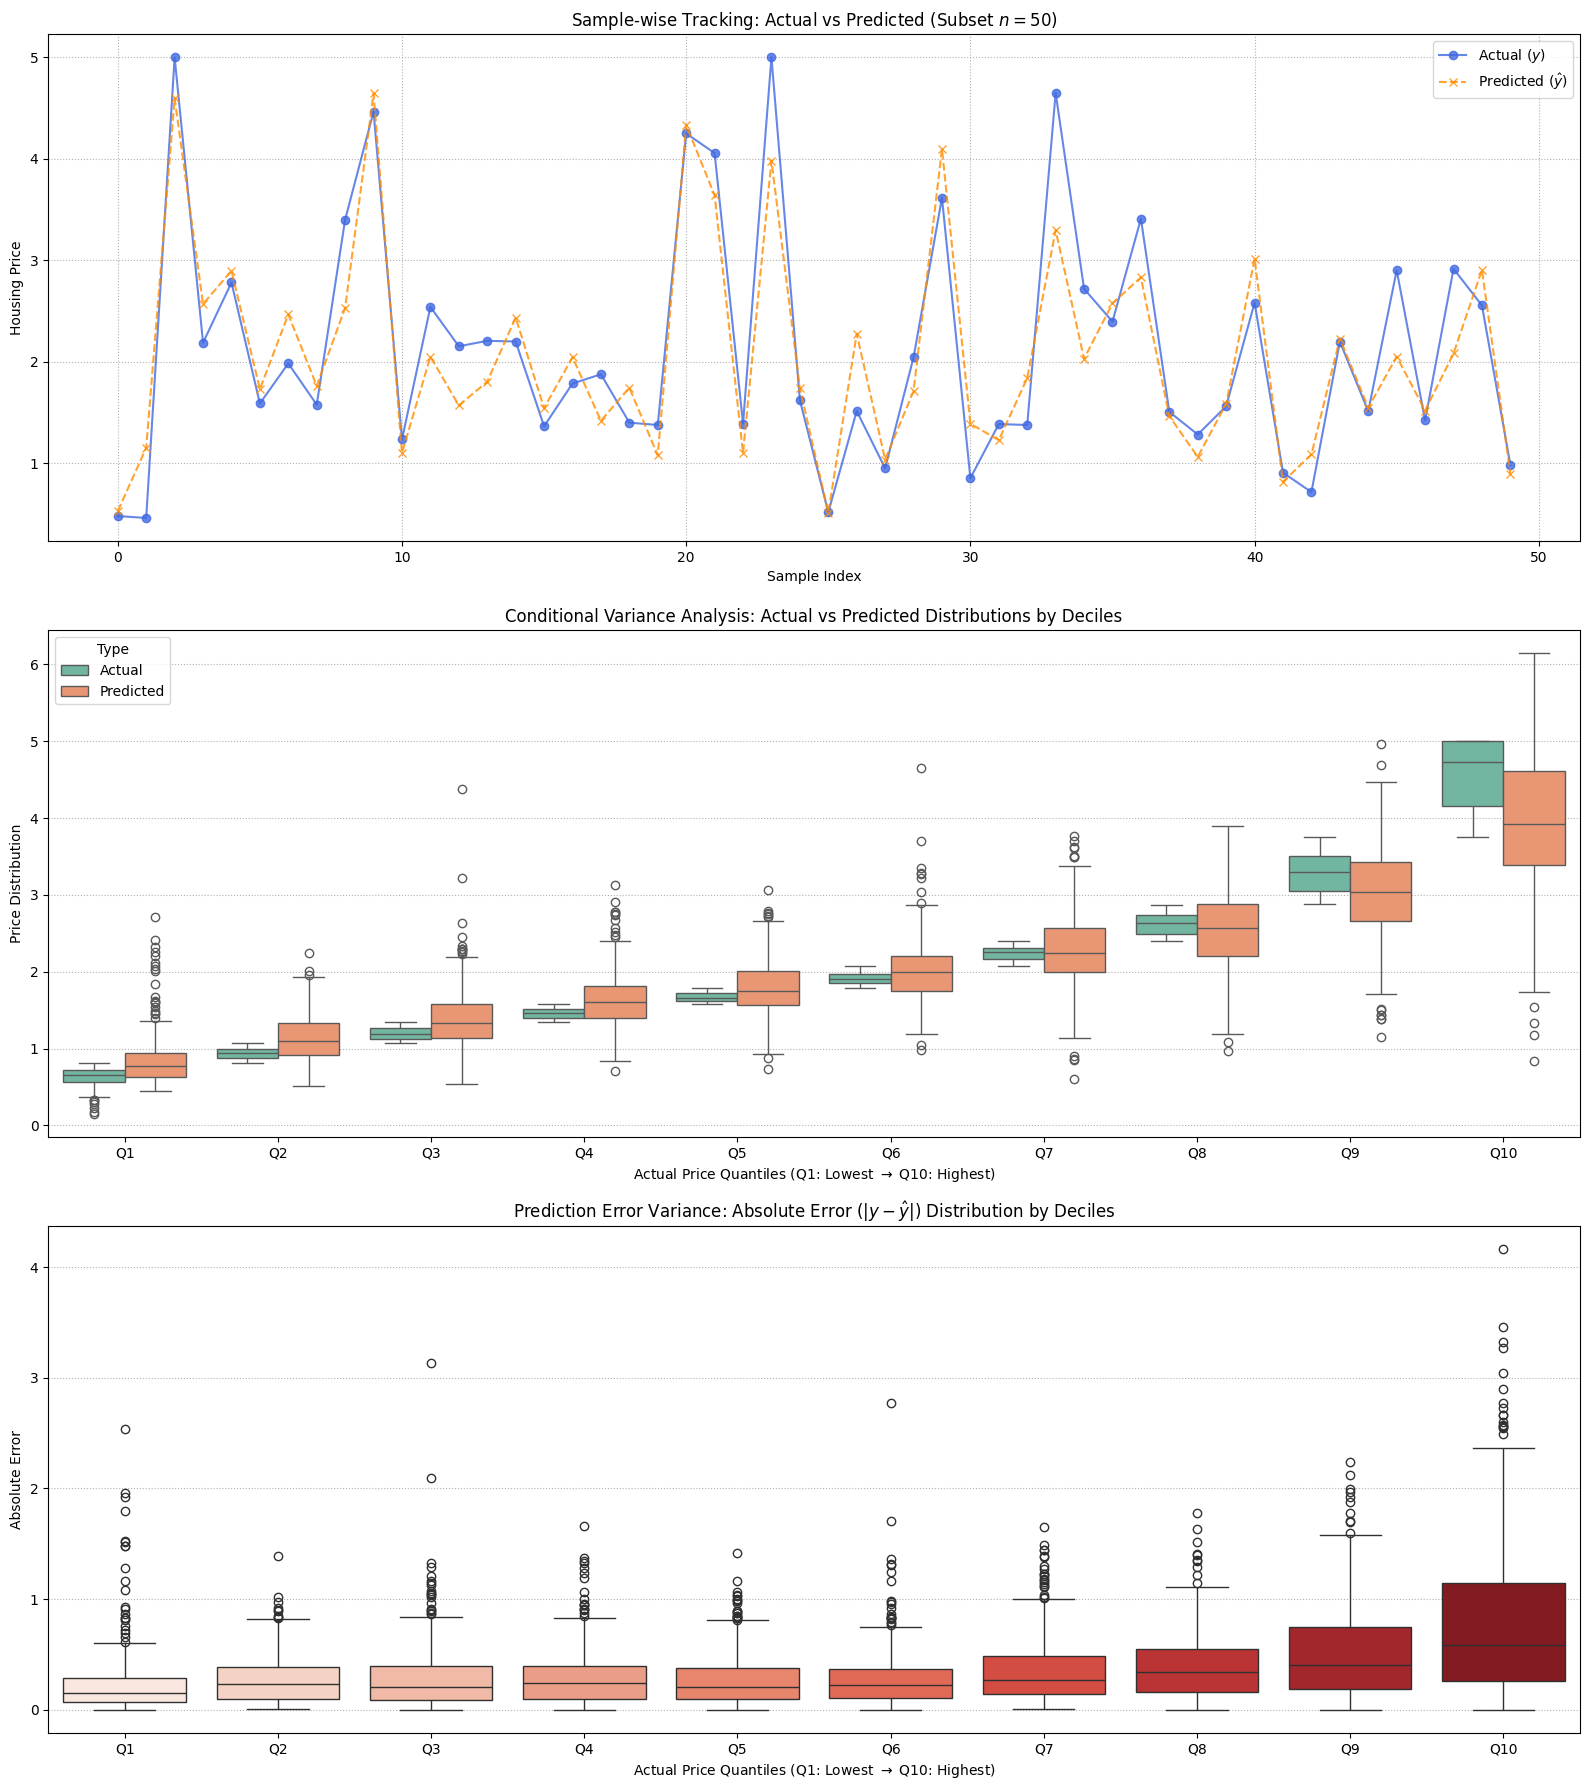

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 이전 셀에서 산출된 actuals_np, predictions_np 변수를 활용함

# 1. 시각화 레이아웃 설정
fig, axes = plt.subplots(3, 1, figsize=(16, 18))

# -----------------------------------------------------------
# [Subplot 1] 소규모 샘플 추출 및 예측 추적 (Tracking)
# -----------------------------------------------------------
num_samples = 50
indices = np.arange(num_samples)

axes[0].plot(indices, actuals_np[:num_samples], marker='o', label='Actual ($y$)', linestyle='-', alpha=0.8, color='royalblue')
axes[0].plot(indices, predictions_np[:num_samples], marker='x', label=r'Predicted ($\hat{y}$)', linestyle='--', alpha=0.8, color='darkorange')
axes[0].set_title(r'Sample-wise Tracking: Actual vs Predicted (Subset $n=50$)')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Housing Price')
axes[0].legend()
axes[0].grid(True, linestyle=':')

# -----------------------------------------------------------
# [Subplot 2] 실제 가격 10분위수(Decile) 기준 분포 비교
# -----------------------------------------------------------
# 분석을 위한 DataFrame 생성 및 오차 계산
df_eval = pd.DataFrame({'Actual': actuals_np, 'Predicted': predictions_np})
df_eval['Absolute_Error'] = np.abs(df_eval['Actual'] - df_eval['Predicted'])

# 실제 가격 기준으로 10분위수(10% 단위) 범주형 변수 생성
df_eval['Quantile'] = pd.qcut(df_eval['Actual'], q=10, labels=[f'Q{i}' for i in range(1, 11)])

# Boxplot 시각화를 위한 데이터 형태 변환 (Melt)
df_melted = pd.melt(df_eval, id_vars=['Quantile'], value_vars=['Actual', 'Predicted'],
                    var_name='Type', value_name='Price')

sns.boxplot(data=df_melted, x='Quantile', y='Price', hue='Type', ax=axes[1], palette='Set2')
axes[1].set_title('Conditional Variance Analysis: Actual vs Predicted Distributions by Deciles')
axes[1].set_xlabel(r'Actual Price Quantiles (Q1: Lowest $\rightarrow$ Q10: Highest)')
axes[1].set_ylabel('Price Distribution')
axes[1].grid(True, linestyle=':', axis='y')

# -----------------------------------------------------------
# [Subplot 3] 분위수별 절대 오차 분산 및 정확도 분석
# -----------------------------------------------------------
sns.boxplot(data=df_eval, x='Quantile', y='Absolute_Error', ax=axes[2], palette='Reds')
axes[2].set_title(r'Prediction Error Variance: Absolute Error ($|y - \hat{y}|$) Distribution by Deciles')
axes[2].set_xlabel(r'Actual Price Quantiles (Q1: Lowest $\rightarrow$ Q10: Highest)')
axes[2].set_ylabel('Absolute Error')
axes[2].grid(True, linestyle=':', axis='y')

plt.tight_layout()
plt.show()

## 학생 실습: 하이퍼파라미터 튜닝 및 모델 최적화 (Hyperparameter Tuning)

제안하는 기본 MLP 모델(Baseline)은 캘리포니아 주택 가격 데이터의 복잡한 비선형성을 완벽히 포착하기에 불충분하며, 과적합(Overfitting)의 위험에 노출되어 있다.

본 실습에서는 모델의 일반화(Generalization) 성능을 극대화하기 위해 직접 네트워크 아키텍처를 수정하고 정규화(Regularization) 기법을 도입함. 코드 내 빈칸(___ 또는 [빈칸])으로 처리된 부분을 수정하여 최적의 $\mathcal{L}_{MSE}$ 및 $R^2$ Score를 도출하시오.

주요 실험 변인:
1. Network Capacity: 은닉층(Hidden Layer)의 깊이 및 노드 수 변경.
2. Activation Function: ReLU의 한계(Dying ReLU)를 극복하기 위한 LeakyReLU, GELU 등의 도입.
3. Regularization: Dropout 확률값 조정 및 Optimizer의 $L_2$ Penalty(weight_decay) 탐색.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# -----------------------------------------------------------
# [실습 1] 모델 아키텍처 재설계
# -----------------------------------------------------------
class TunedRegressionMLP(nn.Module):
    def __init__(self, input_dim):
        super(TunedRegressionMLP, self).__init__()

        # [퀴즈 1] 노드 수를 늘리거나 층(Layer)을 추가하여 모델의 표현력을 조정하시오.
        # 예시: 128 -> 256 등
        self.fc1 = nn.Linear(input_dim, ___)
        self.fc2 = nn.Linear(___, ___)

        # [퀴즈 2] 과적합(Overfitting) 방지를 위해 Dropout 확률(p)을 설정하시오. (예: 0.1 ~ 0.5)
        self.dropout = nn.Dropout(p=___)

        # Output 노드는 회귀이므로 반드시 1이어야 함. 입력 차원은 fc2의 출력과 맞춰야 함.
        self.fc_out = nn.Linear(___, 1)

    def forward(self, x):
        # [퀴즈 3] F.relu 대신 F.leaky_relu 또는 F.gelu를 적용해 보시오.
        x = F.___(self.fc1(x))
        x = self.dropout(x)

        x = F.___(self.fc2(x))
        x = self.dropout(x)

        x = self.fc_out(x) # [주의] 회귀 출력층에는 활성화 함수를 씌우지 않음
        return x

# 모델 객체 생성 (input_dim은 이전 셀에서 정의된 8을 사용)
tuned_model = TunedRegressionMLP(input_dim=X_train.shape[1])

# -----------------------------------------------------------
# [실습 2] 최적화 알고리즘 튜닝
# -----------------------------------------------------------
criterion = nn.MSELoss()

# [퀴즈 4] Learning Rate(lr)와 L2 정규화 페널티(weight_decay) 값을 조정하시오.
# Hint: lr은 보통 1e-4 ~ 1e-2, weight_decay는 1e-5 ~ 1e-2 사이에서 탐색함.
optimizer = optim.Adam(tuned_model.parameters(), lr=___, weight_decay=___)

# [퀴즈 5] 모델이 충분히 수렴할 수 있도록 Epoch 수를 결정하시오. (예: 50, 100)
epochs = ___

# -----------------------------------------------------------
# 훈련 루프 (학생 변경 불필요)
# -----------------------------------------------------------
print("학습을 시작합니다...")
train_loss_history = []

for epoch in range(epochs):
    tuned_model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = tuned_model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_loss_history.append(avg_loss)

    if (epoch+1) % 10 == 0 or epoch == epochs - 1:
        print(f'Epoch [{epoch+1}/{epochs}], MSE Loss: {avg_loss:.4f}')

# -----------------------------------------------------------
# 결과 평가 및 시각화 (학생 변경 불필요)
# -----------------------------------------------------------
tuned_model.eval()
tuned_preds = []
tuned_actuals = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        preds = tuned_model(batch_X)
        tuned_preds.extend(preds.numpy())
        tuned_actuals.extend(batch_y.numpy())

tuned_preds_np = np.array(tuned_preds).flatten()
tuned_actuals_np = np.array(tuned_actuals).flatten()


rmse_tuned = np.sqrt(mean_squared_error(tuned_actuals_np, tuned_preds_np))
r2_tuned = r2_score(tuned_actuals_np, tuned_preds_np)

# -----------------------------------------------------------
# [비교 시각화] Baseline vs Tuned Model 성능 교차 검증
# -----------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 정량적 평가 지표 비교 (Bar Plot)
labels = ['Baseline', 'Tuned']
rmse_vals = [rmse, rmse_tuned]  # rmse: 이전 Baseline 평가에서 산출된 변수
r2_vals = [r2, r2_tuned]        # r2: 이전 Baseline 평가에서 산출된 변수

x = np.arange(len(labels))
width = 0.35

ax1 = axes[0, 0]
rects1 = ax1.bar(x - width/2, rmse_vals, width, label='RMSE ($\downarrow$ better)', color='indianred')
ax2_twin = ax1.twinx()
rects2 = ax2_twin.bar(x + width/2, r2_vals, width, label='$R^2$ Score ($\uparrow$ better)', color='steelblue')

ax1.set_ylabel('RMSE')
ax2_twin.set_ylabel('$R^2$ Score')
ax1.set_title('Quantitative Metrics Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.grid(axis='y', linestyle=':', alpha=0.7)

# 범례 통합
lines, labels_leg = ax1.get_legend_handles_labels()
lines2, labels_leg2 = ax2_twin.get_legend_handles_labels()
ax1.legend(lines + lines2, labels_leg + labels_leg2, loc='center right')

# 2. 학습 곡선 (Tuned Model Loss)
axes[0, 1].plot(train_loss_history, color='purple', lw=2)
axes[0, 1].set_title('Tuned Model: Training Loss ($\mathcal{L}_{MSE}$) Curve')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].grid(True, linestyle=':')

# 3. 실제값 vs 예측값 산점도 오버레이 (Scatter Overlay)
axes[1, 0].scatter(actuals_np, predictions_np, alpha=0.3, color='gray', label='Baseline')
axes[1, 0].scatter(tuned_actuals_np, tuned_preds_np, alpha=0.4, color='teal', label='Tuned')
axes[1, 0].plot([actuals_np.min(), actuals_np.max()],
                [actuals_np.min(), actuals_np.max()], 'r--', lw=2, label='Ideal ($y=\hat{y}$)')
axes[1, 0].set_xlabel('Actual Value ($y$)')
axes[1, 0].set_ylabel('Predicted Value ($\hat{y}$)')
axes[1, 0].set_title('Prediction Distribution: Baseline vs Tuned')
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle=':')

# 4. 잔차(Residual) 밀도 함수 비교 (KDE Plot)
baseline_residuals = actuals_np - predictions_np
tuned_residuals = tuned_actuals_np - tuned_preds_np

sns.kdeplot(baseline_residuals, fill=True, color='gray', label='Baseline Residuals', ax=axes[1, 1])
sns.kdeplot(tuned_residuals, fill=True, color='teal', label='Tuned Residuals', ax=axes[1, 1])
axes[1, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Residuals ($y - \hat{y}$)')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Residual Density Estimation')
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle=':')

plt.tight_layout()
plt.show()